In [ ]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 2.4 MB/s eta 0:00:00


In [ ]:
# @title Importing dependencies

from IPython.display import Image, SVG, display
import os
from pathlib import Path

import random
from tqdm import tqdm
import warnings
import numpy as np
import matplotlib.pyplot as plt
import scipy
import torch
import torchvision
import contextlib
import io

import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [ ]:
#@title set cuda device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 5 # Changed from 3 to 1 to speed up training
        self.NUM_INPUTS = np.int64(28**2) # np.prod(torch.Size([28, 28])) bc images are 28x28 we need 28**2 inputs
        self.NUM_OUTPUTS = 10
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky" # Changed to 'leaky' to align with mlp_net instantiation
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3 # Increased learning rate for better MLP learning


config = Config()

In [ ]:
print(128/5)
print(128/25)
print(5/128)
print(1/25)

25.6
5.12
0.0390625
0.04


# Section 1: Data

In [ ]:
# @title MNIST download
def download_mnist(train_prop=0.65, keep_prop=0.1, neuromatch_magic_normalize = 1):

  valid_prop = 1 - train_prop

  discard_prop = 1 - keep_prop


  # Pick one normalization to use in transform by uncommenting
  if neuromatch_magic_normalize:
    # Below is the Neuromatch Tutorial Transfoam with magic number
    norm_func = transforms.Normalize((0.1307,), (0.3081,))
  else:
    # Below is the snnTorch implementation of normalization
    norm_func = transforms.Normalize((0,), (1,))

  # Define a transform (from https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_5.html )
  transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])


  with contextlib.redirect_stdout(io.StringIO()): #to suppress output

      full_train_set = torchvision.datasets.MNIST(
          root="./data/", train=True, download=True, transform=transform,
          )
      full_test_set = torchvision.datasets.MNIST(
          root="./data/", train=False, download=True, transform=transform,
          )

  train_set, valid_set, _ = torch.utils.data.random_split(
      full_train_set,
      [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
      )
  test_set, _ = torch.utils.data.random_split(
      full_test_set,
      [keep_prop, discard_prop]
      )

  print("Number of examples retained:")
  print(f"  {len(train_set)} (training)")
  print(f"  {len(valid_set)} (validation)")
  print(f"  {len(test_set)} (test)")

  return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist()

Number of examples retained:
  3900 (training)
  2100 (validation)
  1000 (test)


In [ ]:
#@title Dataset transform and Dataloader definition
BATCH_SIZE = config.BATCH_SIZE

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

## Section 2: Model Definition

In [ ]:
#@title Multilayer Perceptron (MLP) Model
class MultiLayerPerceptron(torch.nn.Module):
  """
  Simple multilayer perceptron model class with one hidden layer.
  """

  def __init__(
      self,
      num_inputs=config.NUM_INPUTS,
      num_hidden=config.NUM_HIDDEN,
      num_outputs=config.NUM_OUTPUTS,
      activation_type="leaky",
      bias=False,
      ):
    """
    Initializes a multilayer perceptron with a single hidden layer.

    Arguments:
    - num_inputs (int, optional): number of input units (i.e., image size)
    - num_hidden (int, optional): number of hidden units in the hidden layer
    - num_outputs (int, optional): number of output units (i.e., number of
      classes)
    - activation_type (str, optional): type of activation to use for the hidden
      layer ('sigmoid', 'tanh', 'relu' or 'linear')
    - bias (bool, optional): if True, each linear layer will have biases in
      addition to weights
    """


    super().__init__()

    self.num_inputs = num_inputs
    self.num_hidden = num_hidden
    self.num_outputs = num_outputs
    self.activation_type = activation_type
    self.bias = bias

    # default weights (and biases, if applicable) initialization is used
    # see https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/linear.py
    self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
    self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)

    self._store_initial_weights_biases()

    self._set_activation() # activation on the hidden layer
    # Removed: self.softmax = torch.nn.Softmax(dim=1) # activation on the output layer


  def _store_initial_weights_biases(self):
    """
    Stores a copy of the network's initial weights and biases.
    """

    self.init_lin1_weight = self.lin1.weight.data.clone()
    self.init_lin2_weight = self.lin2.weight.data.clone()
    if self.bias:
      self.init_lin1_bias = self.lin1.bias.data.clone()
      self.init_lin2_bias = self.lin2.bias.data.clone()

  def _set_activation(self):
    """
    Sets the activation function used for the hidden layer.
    """

    if self.activation_type.lower() == "sigmoid":
      self.activation = torch.nn.Sigmoid() # maps to [0, 1]
    elif self.activation_type.lower() == "tanh":
      self.activation = torch.nn.Tanh() # maps to [-1, 1]
    elif self.activation_type.lower() == "relu":
      self.activation = torch.nn.ReLU() # maps to positive
    elif self.activation_type.lower() == "identity":
      self.activation = torch.nn.Identity() # maps to same
    elif self.activation_type.lower() == "leaky":
      self.activation = torch.nn.LeakyReLU(config.BETA) # maps to same
    else:
      raise NotImplementedError(
          f"{self.activation_type} activation type not recognized. Only "
          "'sigmoid', 'relu' and 'identity' have been implemented so far."
          )

  def forward(self, X, y=None):
    """
    Runs a forward pass through the network.

    Arguments:
    - X (torch.Tensor): Batch of input images.
    - y (torch.Tensor, optional): Batch of targets. This variable is not used
      here. However, it may be needed for other learning rules, to it is
      included as an argument here for compatibility.

    Returns:
    - y_pred (torch.Tensor): Predicted targets.
    """

    h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
    y_pred = self.lin2(h) # Changed to output logits directly
    return y_pred

  def forward_backprop(self, X):
    """
    Identical to forward(). Should not be overwritten when creating new
    child classes to implement other learning rules, as this method is used
    to compare the gradients calculated with other learning rules to those
    calculated with backprop.
    """

    h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
    y_pred = self.lin2(h) # Changed to output logits directly
    return y_pred


  def list_parameters(self):
    """
    Returns a list of model names for a gradient dictionary.

    Returns:
    - params_list (list): List of parameter names.
    """

    params_list = list()

    for layer_str in ["lin1", "lin2"]:
      params_list.append(f"{layer_str}_weight")
      if self.bias:
        params_list.append(f"{layer_str}_bias")

    return params_list


  def gather_gradient_dict(self):
    """
    Gathers a gradient dictionary for the model's parameters. Raises a
    runtime error if any parameters have no gradients.

    Returns:
    - gradient_dict (dict): A dictionary of gradients for each parameter.
    """

    params_list = self.list_parameters()

    gradient_dict = dict()
    for param_name in params_list:
      layer_str, param_str = param_name.split("_")
      layer = getattr(self, layer_str)
      grad = getattr(layer, param_str).grad
      if grad is None:
        raise RuntimeError("No gradient was computed")
      gradient_dict[param_name] = grad.detach().clone().numpy()

    return gradient_dict




mlp_net = MultiLayerPerceptron(
    num_hidden =  config.NUM_HIDDEN,
    activation_type = "leaky",
    bias = config.BIAS,
    ).to(device)
print(mlp_net)


MultiLayerPerceptron(
  (lin1): Linear(in_features=784, out_features=100, bias=True)
  (lin2): Linear(in_features=100, out_features=10, bias=True)
  (activation): LeakyReLU(negative_slope=0.8)
)


In [ ]:
#@title Spiking Neural Network (SNN) Model

## Define the SNN model class, which inherits from the MultiLayerPerceptron class
# Define Network

class SNN_MLP(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        # Record the final layer
        spk2_rec = []
        mem2_rec = []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

# Load the network onto CUDA if available
snn_net = SNN_MLP().to(device)
print(snn_net)

SNN_MLP(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (lif2): Leaky()
)


Section 3: Optimizer definition and training loops

In [ ]:
# Backprop Optimizers
mlp_optimizer = torch.optim.Adam(mlp_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_optimizer = torch.optim.Adam(snn_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

# Loss Function
loss = nn.CrossEntropyLoss()

In [ ]:
#@title Model Training Helper Functions
def train_model(MLP, train_loader, valid_loader, optimizer, num_epochs=config.NUM_EPOCHS):
  """
  Train a model for several epochs.

  Arguments:
  - net (torch model, MLP or SNN): Model to train.
  - train_loader (torch dataloader): Dataloader to use to train the model.
  - valid_loader (torch dataloader): Dataloader to use to validate the model.
  - optimizer (torch optimizer): Optimizer to use to update the model.
  - num_epochs (int, optional): Number of epochs to train model.

  Returns:
  - results_dict (dict): Dictionary storing results across epochs on training
    and validation data.
  """

  results_dict = {
      "avg_train_losses": list(),
      "avg_valid_losses": list(),
      "avg_train_accuracies": list(),
      "avg_valid_accuracies": list(),
  }

  for e in tqdm(range(num_epochs)):
    no_train = True if e == 0 else False # to get a baseline
    latest_epoch_results_dict = train_epoch(
        MLP, train_loader, valid_loader, optimizer=optimizer, no_train=no_train
        )

    for key, result in latest_epoch_results_dict.items():
      if key in results_dict.keys() and isinstance(results_dict[key], list):
        results_dict[key].append(latest_epoch_results_dict[key])
      else:
        results_dict[key] = result # copy latest

  return results_dict


def train_epoch(MLP, train_loader, valid_loader, optimizer, no_train=False):
  """
  Train a model for one epoch.

  Arguments:
  - MLP (torch model): Model to train.
  - train_loader (torch dataloader): Dataloader to use to train the model.
  - valid_loader (torch dataloader): Dataloader to use to validate the model.
  - optimizer (torch optimizer): Optimizer to use to update the model.
  - no_train (bool, optional): If True, the model is not trained for the
    current epoch. Allows a baseline (chance) performance to be computed in the
    first epoch before training starts.

  Returns:
  - epoch_results_dict (dict): Dictionary storing epoch results on training
    and validation data.
  """

  ##TODO substitute with Binary Cross Entropy passed as input
  criterion = torch.nn.NLLLoss()

  epoch_results_dict = dict()
  for dataset in ["train", "valid"]:
    for sub_str in ["correct_by_class", "seen_by_class"]:
      epoch_results_dict[f"{dataset}_{sub_str}"] = {
          i:0 for i in range(MLP.num_outputs)
          }

  MLP.train()
  train_losses, train_acc = list(), list()
  for X, y in train_loader:
    y_pred = MLP(X, y=y)
    loss = criterion(torch.log(y_pred), y)
    acc = (torch.argmax(y_pred.detach(), axis=1) == y).sum() / len(y)
    train_losses.append(loss.item() * len(y))
    train_acc.append(acc.item() * len(y))
    update_results_by_class_in_place(
        y, y_pred.detach(), epoch_results_dict, dataset="train",
        num_classes=MLP.num_outputs
        )
    optimizer.zero_grad()
    if not no_train:
      loss.backward()
      optimizer.step()

  num_items = len(train_loader.dataset)
  epoch_results_dict["avg_train_losses"] = np.sum(train_losses) / num_items
  epoch_results_dict["avg_train_accuracies"] = np.sum(train_acc) / num_items * 100

  MLP.eval()
  valid_losses, valid_acc = list(), list()
  with torch.no_grad():
    for X, y in valid_loader:
      y_pred = MLP(X)
      loss = criterion(torch.log(y_pred), y)
      acc = (torch.argmax(y_pred, axis=1) == y).sum() / len(y)
      valid_losses.append(loss.item() * len(y))
      valid_acc.append(acc.item() * len(y))
      update_results_by_class_in_place(
          y, y_pred.detach(), epoch_results_dict, dataset="valid"
          )

  num_items = len(valid_loader.dataset)
  epoch_results_dict["avg_valid_losses"] = np.sum(valid_losses) / num_items
  epoch_results_dict["avg_valid_accuracies"] = np.sum(valid_acc) / num_items * 100

  return epoch_results_dict


def update_results_by_class_in_place(y, y_pred, result_dict, dataset="train",
                                     num_classes=10):
  """
  Updates results dictionary in place during a training epoch by adding data
  needed to compute the accuracies for each class.

  Arguments:
  - y (torch Tensor): target labels
  - y_pred (torch Tensor): predicted targets
  - result_dict (dict): Dictionary storing epoch results on training
    and validation data.
  - dataset (str, optional): Dataset for which results are being added.
  - num_classes (int, optional): Number of classes.
  """

  correct_by_class = None
  seen_by_class = None

  y_pred = np.argmax(y_pred, axis=1)
  if len(y) != len(y_pred):
    raise RuntimeError("Number of predictions does not match number of targets.")

  for i in result_dict[f"{dataset}_seen_by_class"].keys():
    idxs = np.where(y == int(i))[0]
    result_dict[f"{dataset}_seen_by_class"][int(i)] += len(idxs)

    num_correct = int(sum(y[idxs] == y_pred[idxs]))
    result_dict[f"{dataset}_correct_by_class"][int(i)] += num_correct


# --- Smoothing function ---
def smooth_curve(data, window_size):
    if window_size <= 1: # No smoothing needed
        return data
    if len(data) < window_size: # Not enough data to smooth with given window
        return [np.mean(data)] * len(data)
    smoothed_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        smoothed_data.append(np.mean(data[start_index:end_index + 1]))
    return smoothed_data

In [ ]:
#@title Train snn model
num_epochs = config.NUM_EPOCHS
loss_hist_snn = []
test_loss_hist_snn = []
train_acc_hist_snn = []  # New: Store training accuracy per minibatch
test_acc_hist_snn = []   # New: Store test accuracy per minibatch
counter = 0
num_steps = config.NUM_SNN_TIMESTEPS
dtype = torch.float

# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target
def print_batch_accuracy(data, targets, train=False):
    output, _ = snn_net(data.view(config.BATCH_SIZE, -1))
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())
    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")
def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

# Outer training loop
for epoch in range(num_epochs):
    iter_counter = 0
    train_batch = iter(train_loader)
    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)
        # forward pass
        snn_net.train()
        spk_rec, mem_rec = snn_net(data.view(BATCH_SIZE, -1))
        # initialize the loss & sum over time
        loss_val = torch.zeros((1), dtype=dtype, device=device)
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)
        loss_val /= num_steps # Normalize SNN loss by number of timesteps
        # Gradient calculation + weight update
        snn_optimizer.zero_grad()
        loss_val.backward()
        snn_optimizer.step()
        # Store loss history for future plotting
        loss_hist_snn.append(loss_val.item())

        # New: Calculate and store training accuracy
        _, predicted_train_labels = spk_rec.sum(dim=0).max(1) # Sum spikes over time and get the class with max spikes
        train_acc = (predicted_train_labels == targets).float().mean().item()
        train_acc_hist_snn.append(train_acc)

        # Test set
        with torch.no_grad():
            snn_net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)
            # Test set forward pass
            test_spk, test_mem = snn_net(test_data.view(BATCH_SIZE, -1))
            # Test set loss
            test_loss = torch.zeros((1), dtype=dtype, device=device)
            for step in range(num_steps):

                  test_loss += loss(test_mem[step], test_targets)
            test_loss /= num_steps # Normalize SNN test loss by number of timesteps
            test_loss_hist_snn.append(test_loss.item())

            # New: Calculate and store test accuracy
            _, predicted_test_labels = test_spk.sum(dim=0).max(1)
            test_acc = (predicted_test_labels == test_targets).float().mean().item()
            test_acc_hist_snn.append(test_acc)

            # Print train/test loss/accuracy
            if counter % 50 == 0:
                train_printer(
                    data, targets, epoch,
                    counter, iter_counter,
                    loss_hist_snn, test_loss_hist_snn,
                    test_data, test_targets)
            counter += 1
            iter_counter +=1

Epoch 0, Iteration 0
Train Set Loss: 2.37
Test Set Loss: 2.09
Train set accuracy for a single minibatch: 46.09%
Test set accuracy for a single minibatch: 33.59%


Epoch 0, Iteration 50
Train Set Loss: 0.47
Test Set Loss: 0.52
Train set accuracy for a single minibatch: 89.06%
Test set accuracy for a single minibatch: 84.38%


Epoch 0, Iteration 100
Train Set Loss: 0.40
Test Set Loss: 0.53
Train set accuracy for a single minibatch: 87.50%
Test set accuracy for a single minibatch: 82.81%


Epoch 0, Iteration 150
Train Set Loss: 0.31
Test Set Loss: 0.29
Train set accuracy for a single minibatch: 91.41%
Test set accuracy for a single minibatch: 89.06%


Epoch 1, Iteration 13
Train Set Loss: 0.26
Test Set Loss: 0.26
Train set accuracy for a single minibatch: 94.53%
Test set accuracy for a single minibatch: 90.62%


Epoch 1, Iteration 63
Train Set Loss: 0.35
Test Set Loss: 0.30
Train set accuracy for a single minibatch: 87.50%
Test set accuracy for a single minibatch: 93.75%


Epoch 1, Iterat

In [ ]:
#@title Train MLP model
num_epochs = config.NUM_EPOCHS
loss_hist_mlp = []
test_loss_hist_mlp = []
train_acc_hist_mlp = []
test_acc_hist_mlp = []
counter_mlp = 0 # Use a different counter for MLP to avoid conflict
dtype = torch.float # Retain dtype definition for consistency

# Using CrossEntropyLoss directly on logits
criterion_mlp = nn.CrossEntropyLoss()

# pass data into the network
def print_batch_accuracy_mlp(data, targets, train=False):
    # MLP forward pass
    y_pred = mlp_net(data.view(config.BATCH_SIZE, -1)) # Outputs logits
    predicted_labels = torch.argmax(y_pred, dim=1) # Get predicted labels from logits
    acc = (targets == predicted_labels).float().mean().item()
    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer_mlp(
    data, targets, epoch,
    counter_mlp, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter_mlp]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter_mlp]:.2f}")
    print_batch_accuracy_mlp(data, targets, train=True)
    print_batch_accuracy_mlp(test_data, test_targets, train=False)
    print("\n")

# Outer training loop
for epoch in range(num_epochs):
    iter_counter = 0
    train_batch = iter(train_loader)
    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)

        # MLP forward pass
        mlp_net.train()
        y_pred = mlp_net(data.view(config.BATCH_SIZE, -1))

        # Loss calculation: use CrossEntropyLoss with logits
        loss_val = criterion_mlp(y_pred, targets)

        # Gradient calculation + weight update
        mlp_optimizer.zero_grad()
        loss_val.backward()
        mlp_optimizer.step()

        # Store loss history for future plotting
        loss_hist_mlp.append(loss_val.item())

        # Calculate and store training accuracy
        predicted_train_labels = torch.argmax(y_pred, dim=1)
        train_acc = (predicted_train_labels == targets).float().mean().item()
        train_acc_hist_mlp.append(train_acc)

        # Test set
        with torch.no_grad():
            mlp_net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)

            # Test set forward pass
            test_y_pred = mlp_net(test_data.view(config.BATCH_SIZE, -1))

            # Test set loss
            test_loss = criterion_mlp(test_y_pred, test_targets)
            test_loss_hist_mlp.append(test_loss.item())

            # Calculate and store test accuracy
            predicted_test_labels = torch.argmax(test_y_pred, dim=1)
            test_acc = (predicted_test_labels == test_targets).float().mean().item()
            test_acc_hist_mlp.append(test_acc)

            # Print train/test loss/accuracy
            if counter_mlp % 50 == 0:
                train_printer_mlp(
                    data, targets, epoch,
                    counter_mlp, iter_counter,
                    loss_hist_mlp, test_loss_hist_mlp,
                    test_data, test_targets)
            counter_mlp += 1
            iter_counter +=1

Epoch 0, Iteration 0
Train Set Loss: 2.30
Test Set Loss: 2.15
Train set accuracy for a single minibatch: 32.03%
Test set accuracy for a single minibatch: 20.31%


Epoch 0, Iteration 50
Train Set Loss: 0.41
Test Set Loss: 0.47
Train set accuracy for a single minibatch: 88.28%
Test set accuracy for a single minibatch: 85.16%


Epoch 0, Iteration 100
Train Set Loss: 0.40
Test Set Loss: 0.33
Train set accuracy for a single minibatch: 89.06%
Test set accuracy for a single minibatch: 89.84%


Epoch 0, Iteration 150
Train Set Loss: 0.35
Test Set Loss: 0.24
Train set accuracy for a single minibatch: 89.84%
Test set accuracy for a single minibatch: 94.53%


Epoch 1, Iteration 13
Train Set Loss: 0.39
Test Set Loss: 0.26
Train set accuracy for a single minibatch: 89.84%
Test set accuracy for a single minibatch: 93.75%


Epoch 1, Iteration 63
Train Set Loss: 0.35
Test Set Loss: 0.22
Train set accuracy for a single minibatch: 89.84%
Test set accuracy for a single minibatch: 92.19%


Epoch 1, Iterat

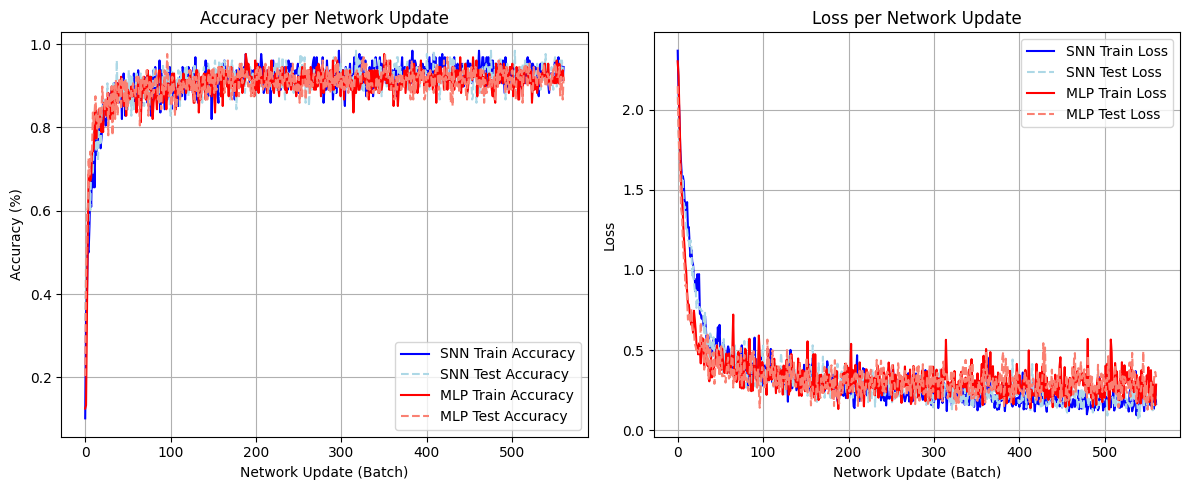

In [ ]:
plt.figure(figsize=(12, 5))

# Plotting Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc_hist_snn, label='SNN Train Accuracy', color='blue')
plt.plot(test_acc_hist_snn, label='SNN Test Accuracy', color='lightblue', linestyle='--')
plt.plot(train_acc_hist_mlp, label='MLP Train Accuracy', color='red')
plt.plot(test_acc_hist_mlp, label='MLP Test Accuracy', color='salmon', linestyle='--')
plt.title('Accuracy per Network Update')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(loss_hist_snn, label='SNN Train Loss', color='blue')
plt.plot(test_loss_hist_snn, label='SNN Test Loss', color='lightblue', linestyle='--')
plt.plot(loss_hist_mlp, label='MLP Train Loss', color='red')
plt.plot(test_loss_hist_mlp, label='MLP Test Loss', color='salmon', linestyle='--')
plt.title('Loss per Network Update')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Training Classical SNN (loss aggregated every timestep) ---
Starting training for Classical SNN...
Classical SNN Epoch 0, Iteration 0
Classical SNN Train Set Loss: 2.36
Classical SNN Test Set Loss: 2.05
Classical SNN Train set accuracy for a single minibatch: 38.28%
Classical SNN Test set accuracy for a single minibatch: 28.91%


Classical SNN Epoch 0, Iteration 50
Classical SNN Train Set Loss: 0.52
Classical SNN Test Set Loss: 0.43
Classical SNN Train set accuracy for a single minibatch: 85.94%
Classical SNN Test set accuracy for a single minibatch: 85.94%


Classical SNN Epoch 0, Iteration 100
Classical SNN Train Set Loss: 0.31
Classical SNN Test Set Loss: 0.38
Classical SNN Train set accuracy for a single minibatch: 95.31%
Classical SNN Test set accuracy for a single minibatch: 89.06%


Classical SNN Epoch 0, Iteration 150
Classical SNN Train Set Loss: 0.16
Classical SNN Test Set Loss: 0.33
Classical SNN Train set accuracy for a single minibatch: 94.53%
Classical SNN Test set a

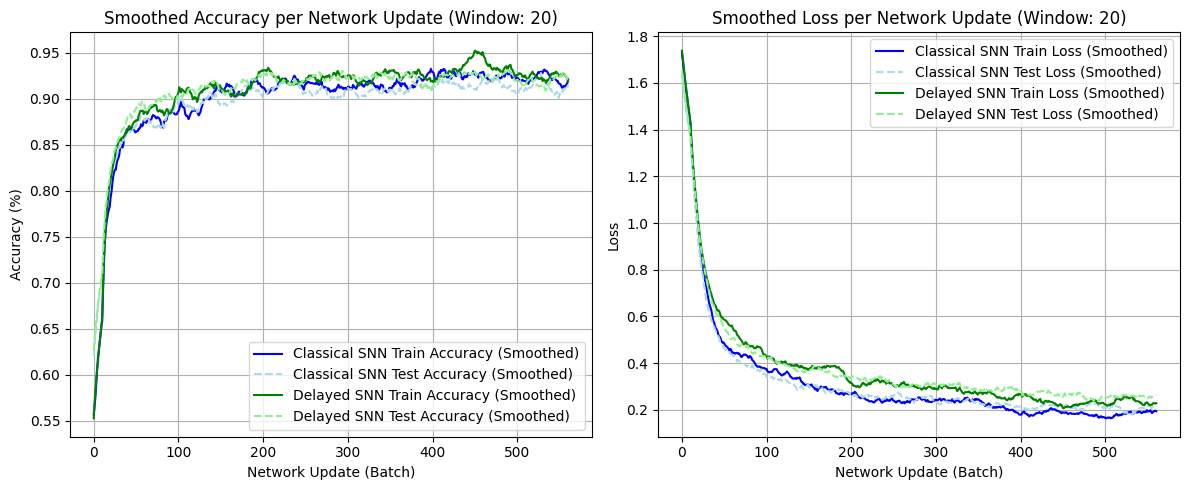

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define a new SNN model instance and its optimizer for both variants ---
# The SNN_MLP class is already defined in a previous cell.
dtype = torch.float # Define dtype for consistency

# Classical SNN (loss aggregated every timestep)
snn_net_classical = SNN_MLP().to(device)
snn_optimizer_classical = torch.optim.Adam(snn_net_classical.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

# Delayed Loss SNN (loss aggregated every 5 timesteps)
snn_net_delayed = SNN_MLP().to(device)
snn_optimizer_delayed = torch.optim.Adam(snn_net_delayed.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

# --- Define a reusable SNN training function ---
def train_snn_variant(snn_model, snn_optimizer, train_loader, test_loader,
                      num_epochs, num_steps, loss_aggregation_interval, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0

    print(f"Starting training for {model_name}...")

    # Helper function to print accuracy for a single batch
    def print_batch_accuracy_variant(data, targets, train=False):
        output, _ = snn_model(data.view(config.BATCH_SIZE, -1))
        _, idx = output.sum(dim=0).max(1)
        acc = np.mean((targets == idx).detach().cpu().numpy())
        if train:
            print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        else:
            print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    # Helper function to print training progress
    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        print_batch_accuracy_variant(data, targets, train=True)
        print_batch_accuracy_variant(test_data, test_targets, train=False)
        print("\n")

    # Outer training loop
    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader) # Create a new iterator for each epoch
        test_loader_iter = iter(test_loader) # Create a new iterator for test batches for each epoch

        # Minibatch training loop
        for data, targets in train_batch_iter:
            data = data.to(device)
            targets = targets.to(device)

            # Forward pass
            snn_model.train()
            spk_rec, mem_rec = snn_model(data.view(config.BATCH_SIZE, -1))

            # Initialize loss and sum over effective timesteps
            loss_val = torch.zeros((1), dtype=dtype, device=device)
            effective_loss_steps = 0
            for step in range(num_steps):
                if (step % loss_aggregation_interval) == 0:
                    loss_val += loss(mem_rec[step], targets)
                    effective_loss_steps += 1

            # Normalize SNN loss by number of effective timesteps
            if effective_loss_steps > 0:
                loss_val /= effective_loss_steps

            # Gradient calculation + weight update
            snn_optimizer.zero_grad()
            loss_val.backward()
            snn_optimizer.step()

            # Store loss history
            loss_hist.append(loss_val.item())

            # Calculate and store training accuracy
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation (within training loop, similar to previous cell's pattern)
            with torch.no_grad():
                snn_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    # Reset test_loader_iter if exhausted within an epoch
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                # Test set forward pass
                test_spk, test_mem = snn_model(test_data.view(config.BATCH_SIZE, -1))

                # Test set loss calculation with specified aggregation interval
                test_loss = torch.zeros((1), dtype=dtype, device=device)
                effective_test_loss_steps = 0
                for step in range(num_steps):
                    if (step % loss_aggregation_interval) == 0:
                        test_loss += loss(test_mem[step], test_targets)
                        effective_test_loss_steps += 1

                if effective_test_loss_steps > 0:
                    test_loss /= effective_test_loss_steps

                test_loss_hist.append(test_loss.item())

                # Calculate and store test accuracy
                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                # Print train/test loss/accuracy periodically
                if counter % 50 == 0:
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter +=1
    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Train both SNN variants ---
print("\n--- Training Classical SNN (loss aggregated every timestep) ---")
loss_hist_classical_snn, test_loss_hist_classical_snn, train_acc_hist_classical_snn, test_acc_hist_classical_snn = \
    train_snn_variant(snn_net_classical, snn_optimizer_classical, train_loader, test_loader,
                      config.NUM_EPOCHS, config.NUM_SNN_TIMESTEPS, 1, "Classical SNN")

print("\n--- Training Delayed Loss SNN (loss aggregated every 5 timesteps) ---")
loss_hist_delayed_snn, test_loss_hist_delayed_snn, train_acc_hist_delayed_snn, test_acc_hist_delayed_snn = \
    train_snn_variant(snn_net_delayed, snn_optimizer_delayed, train_loader, test_loader,
                      config.NUM_EPOCHS, config.NUM_SNN_TIMESTEPS, 5, "Delayed SNN")

SMOOTHING_WINDOW = 20 # Define a smoothing window size

# Apply smoothing to all history lists
smoothed_train_acc_classical_snn = smooth_curve(train_acc_hist_classical_snn, SMOOTHING_WINDOW)
smoothed_test_acc_classical_snn = smooth_curve(test_acc_hist_classical_snn, SMOOTHING_WINDOW)
smoothed_loss_hist_classical_snn = smooth_curve(loss_hist_classical_snn, SMOOTHING_WINDOW)
smoothed_test_loss_hist_classical_snn = smooth_curve(test_loss_hist_classical_snn, SMOOTHING_WINDOW)

smoothed_train_acc_delayed_snn = smooth_curve(train_acc_hist_delayed_snn, SMOOTHING_WINDOW)
smoothed_test_acc_delayed_snn = smooth_curve(test_acc_hist_delayed_snn, SMOOTHING_WINDOW)
smoothed_loss_hist_delayed_snn = smooth_curve(loss_hist_delayed_snn, SMOOTHING_WINDOW)
smoothed_test_loss_hist_delayed_snn = smooth_curve(test_loss_hist_delayed_snn, SMOOTHING_WINDOW)


# --- Plot the smoothed results for comparison ---
plt.figure(figsize=(12, 5))

# Plotting Accuracy
plt.subplot(1, 2, 1)
plt.plot(smoothed_train_acc_classical_snn, label='Classical SNN Train Accuracy (Smoothed)', color='blue')
plt.plot(smoothed_test_acc_classical_snn, label='Classical SNN Test Accuracy (Smoothed)', color='lightblue', linestyle='--')
plt.plot(smoothed_train_acc_delayed_snn, label='Delayed SNN Train Accuracy (Smoothed)', color='green')
plt.plot(smoothed_test_acc_delayed_snn, label='Delayed SNN Test Accuracy (Smoothed)', color='lightgreen', linestyle='--')
plt.title(f'Smoothed Accuracy per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(smoothed_loss_hist_classical_snn, label='Classical SNN Train Loss (Smoothed)', color='blue')
plt.plot(smoothed_test_loss_hist_classical_snn, label='Classical SNN Test Loss (Smoothed)', color='lightblue', linestyle='--')
plt.plot(smoothed_loss_hist_delayed_snn, label='Delayed SNN Train Loss (Smoothed)', color='green')
plt.plot(smoothed_test_loss_hist_delayed_snn, label='Delayed SNN Test Loss (Smoothed)', color='lightgreen', linestyle='--')
plt.title(f'Smoothed Loss per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Training SNN with loss aggregation every 1 timesteps ---
Starting training for SNN (Delay: 1)...
SNN (Delay: 1) Epoch 0, Iteration 0
SNN (Delay: 1) Train Set Loss: 2.47
SNN (Delay: 1) Test Set Loss: 2.18
SNN (Delay: 1) Train set accuracy for a single minibatch: 35.94%
SNN (Delay: 1) Test set accuracy for a single minibatch: 28.12%


SNN (Delay: 1) Epoch 0, Iteration 50
SNN (Delay: 1) Train Set Loss: 0.54
SNN (Delay: 1) Test Set Loss: 0.46
SNN (Delay: 1) Train set accuracy for a single minibatch: 92.97%
SNN (Delay: 1) Test set accuracy for a single minibatch: 90.62%


SNN (Delay: 1) Epoch 0, Iteration 100
SNN (Delay: 1) Train Set Loss: 0.34
SNN (Delay: 1) Test Set Loss: 0.45
SNN (Delay: 1) Train set accuracy for a single minibatch: 92.19%
SNN (Delay: 1) Test set accuracy for a single minibatch: 88.28%


SNN (Delay: 1) Epoch 0, Iteration 150
SNN (Delay: 1) Train Set Loss: 0.28
SNN (Delay: 1) Test Set Loss: 0.31
SNN (Delay: 1) Train set accuracy for a single minibatch: 92.97%
SNN (De

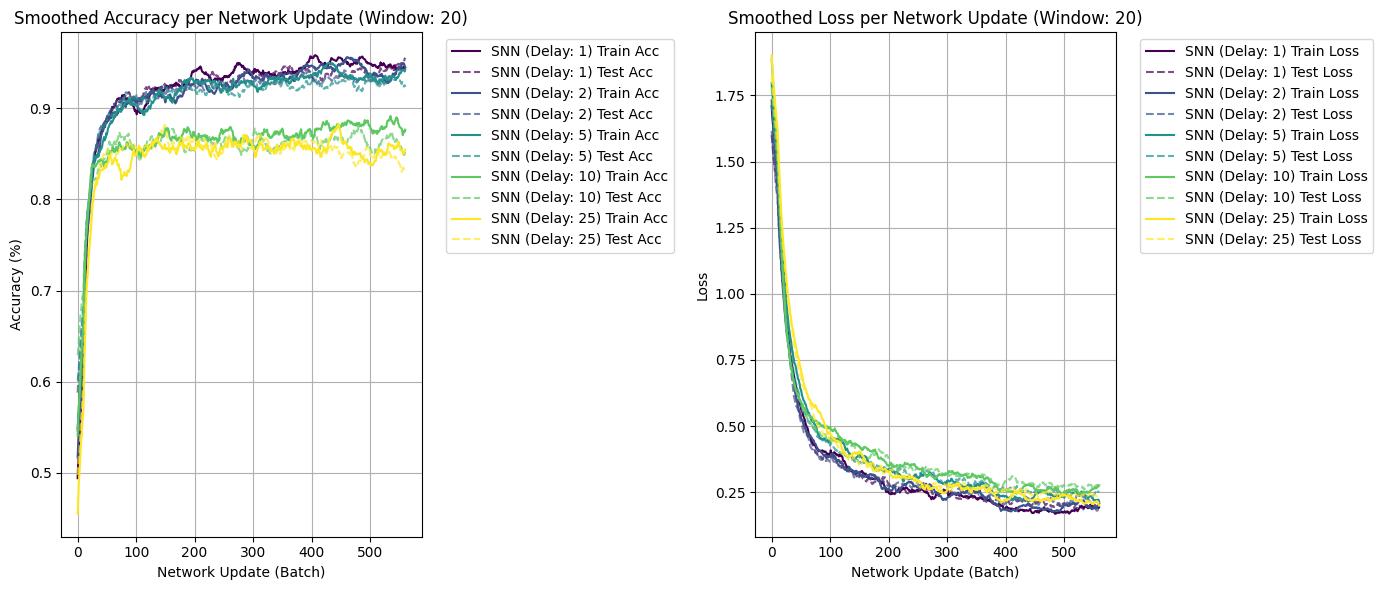

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Define the different loss aggregation intervals to test
loss_intervals = [1, 2, 5, 10, 25] # Including 1 for classical, and others for varying delays

all_snn_results = {}

# Assuming SNN_MLP, device, config, train_loader, test_loader, loss, smooth_curve, train_snn_variant are available from previous cells.

for interval in loss_intervals:
    print(f"\n--- Training SNN with loss aggregation every {interval} timesteps ---")

    # Create a new SNN model instance and its optimizer for each variant
    current_snn_net = SNN_MLP().to(device)
    current_snn_optimizer = torch.optim.Adam(current_snn_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    model_name = f"SNN (Delay: {interval})"
    loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
        train_snn_variant(current_snn_net, current_snn_optimizer, train_loader, test_loader,
                          config.NUM_EPOCHS, config.NUM_SNN_TIMESTEPS, interval, model_name)

    # Store raw histories
    all_snn_results[interval] = {
        'train_acc': train_acc_hist,
        'test_acc': test_acc_hist,
        'train_loss': loss_hist,
        'test_loss': test_loss_hist
    }

# Apply smoothing to all collected histories
SMOOTHING_WINDOW = 20 # Re-using the same smoothing window from the previous cell

for interval, histories in all_snn_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

# --- Plot the smoothed results for comparison ---
plt.figure(figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(loss_intervals))) # Use a colormap for distinct colors

# Plotting Accuracy
plt.subplot(1, 2, 1)
for i, interval in enumerate(loss_intervals):
    results = all_snn_results[interval]
    plt.plot(results['smoothed_train_acc'], label=f'SNN (Delay: {interval}) Train Acc', color=colors[i])
    plt.plot(results['smoothed_test_acc'], label=f'SNN (Delay: {interval}) Test Acc', color=colors[i], linestyle='--', alpha=0.7)
plt.title(f'Smoothed Accuracy per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside for clarity
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
for i, interval in enumerate(loss_intervals):
    results = all_snn_results[interval]
    plt.plot(results['smoothed_train_loss'], label=f'SNN (Delay: {interval}) Train Loss', color=colors[i])
    plt.plot(results['smoothed_test_loss'], label=f'SNN (Delay: {interval}) Test Loss', color=colors[i], linestyle='--', alpha=0.7)
plt.title(f'Smoothed Loss per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside for clarity
plt.grid(True)

plt.tight_layout()
plt.show()

Starting training for MLP (GA: 1) (Grad Accumulation: 1)...
MLP (GA: 1) Epoch 0, Iteration 0
MLP (GA: 1) Train Set Loss: 2.41
MLP (GA: 1) Test Set Loss: 2.17
MLP (GA: 1) Train set accuracy for a single minibatch: 35.94%
MLP (GA: 1) Test set accuracy for a single minibatch: 25.78%


MLP (GA: 1) Epoch 0, Iteration 50
MLP (GA: 1) Train Set Loss: 0.47
MLP (GA: 1) Test Set Loss: 0.41
MLP (GA: 1) Train set accuracy for a single minibatch: 82.81%
MLP (GA: 1) Test set accuracy for a single minibatch: 89.84%


MLP (GA: 1) Epoch 0, Iteration 100
MLP (GA: 1) Train Set Loss: 0.31
MLP (GA: 1) Test Set Loss: 0.26
MLP (GA: 1) Train set accuracy for a single minibatch: 88.28%
MLP (GA: 1) Test set accuracy for a single minibatch: 90.62%


MLP (GA: 1) Epoch 0, Iteration 150
MLP (GA: 1) Train Set Loss: 0.25
MLP (GA: 1) Test Set Loss: 0.25
MLP (GA: 1) Train set accuracy for a single minibatch: 92.19%
MLP (GA: 1) Test set accuracy for a single minibatch: 96.09%


MLP (GA: 1) Epoch 1, Iteration 13
MLP (GA: 

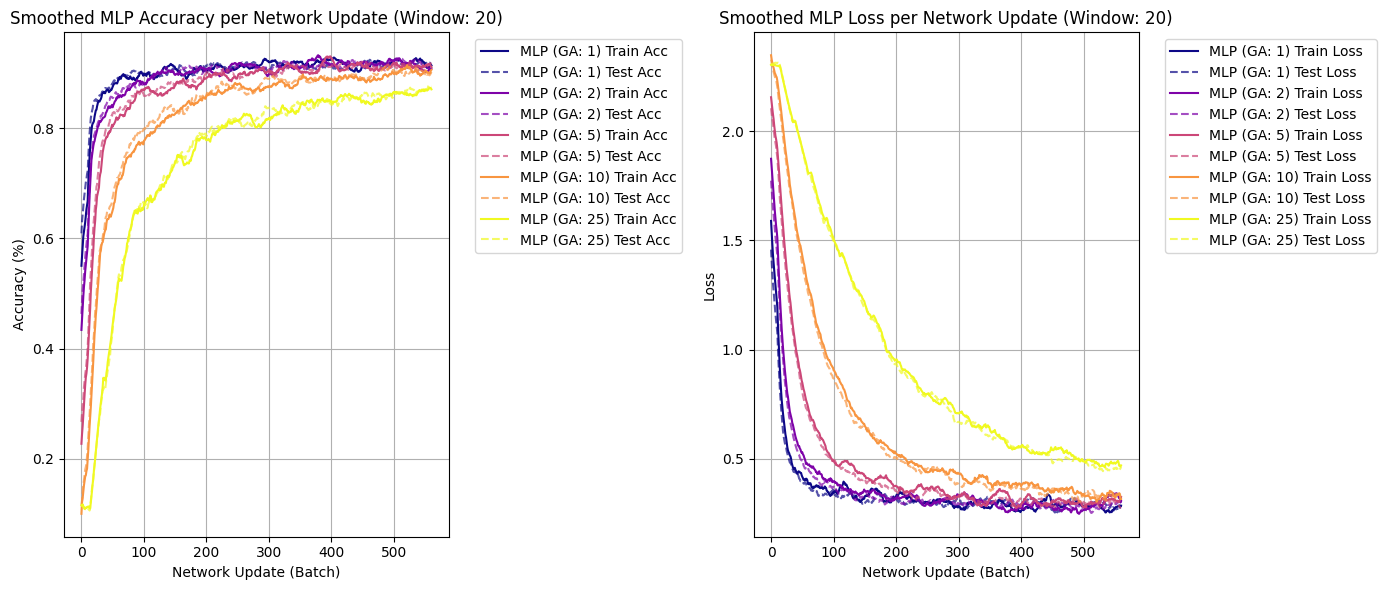

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Define the different gradient accumulation intervals to test for MLP
gradient_accumulation_intervals = [1, 2, 5, 10, 25] # 1 means update every batch (classical MLP)

all_mlp_results = {}

# Assuming MultiLayerPerceptron, device, config, train_loader, test_loader, nn.CrossEntropyLoss, smooth_curve are available

# Define the MLP training function for varying gradient accumulation
def train_mlp_variant(mlp_model, mlp_optimizer, train_loader, test_loader,
                      num_epochs, gradient_accumulation_steps, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    criterion_mlp = nn.CrossEntropyLoss() # Ensure loss function is defined

    print(f"Starting training for {model_name} (Grad Accumulation: {gradient_accumulation_steps})...")

    def print_batch_accuracy_variant(data, targets, train=False):
        mlp_model.eval()
        y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
        predicted_labels = torch.argmax(y_pred, dim=1)
        acc = (targets == predicted_labels).float().mean().item()
        if train:
            print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        else:
            print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        # Note: loss_hist_curr[current_counter] is already the original loss value for plotting
        print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        print_batch_accuracy_variant(data, targets, train=True)
        print_batch_accuracy_variant(test_data, test_targets, train=False)
        print("\n")

    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        mlp_optimizer.zero_grad() # Zero gradients at the start of each accumulation cycle (or epoch for first batch)

        for batch_idx, (data, targets) in enumerate(train_batch_iter):
            data = data.to(device)
            targets = targets.to(device)

            mlp_model.train()
            y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
            loss_val = criterion_mlp(y_pred, targets)

            # Scale the loss by the accumulation steps for correct gradient averaging
            loss_val_for_backward = loss_val / gradient_accumulation_steps
            loss_val_for_backward.backward()

            # Store the original (unscaled) loss for plotting
            loss_hist.append(loss_val.item())

            # Calculate and store training accuracy (per batch)
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Perform optimizer step only after accumulation steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                mlp_optimizer.step()
                mlp_optimizer.zero_grad()

            # Test set evaluation (run for every training batch for consistent plotting)
            with torch.no_grad():
                mlp_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader) # Reset if exhausted
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_y_pred = mlp_model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion_mlp(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                if counter % 50 == 0: # Print progress periodically
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter += 1

        # Handle remaining gradients if train_loader size is not a multiple of gradient_accumulation_steps
        # This ensures any accumulated gradients are applied before the epoch ends.
        if (batch_idx + 1) % gradient_accumulation_steps != 0:
            mlp_optimizer.step()
            mlp_optimizer.zero_grad()

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


# Run training for each gradient accumulation interval
for interval in gradient_accumulation_intervals:
    # Create a new MLP model instance and its optimizer for each variant
    current_mlp_net = MultiLayerPerceptron(
        num_hidden =  config.NUM_HIDDEN,
        activation_type = "leaky",
        bias = config.BIAS,
        ).to(device)
    current_mlp_optimizer = torch.optim.Adam(current_mlp_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    model_name = f"MLP (GA: {interval})" # GA for Gradient Accumulation
    loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
        train_mlp_variant(current_mlp_net, current_mlp_optimizer, train_loader, test_loader,
                          config.NUM_EPOCHS, interval, model_name)

    # Store raw histories
    all_mlp_results[interval] = {
        'train_acc': train_acc_hist,
        'test_acc': test_acc_hist,
        'train_loss': loss_hist,
        'test_loss': test_loss_hist
    }

# Apply smoothing to all collected histories
SMOOTHING_WINDOW = 20

for interval, histories in all_mlp_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)


# --- Plot the smoothed results for comparison ---
plt.figure(figsize=(14, 6))

colors = plt.cm.plasma(np.linspace(0, 1, len(gradient_accumulation_intervals))) # Using a different colormap for MLP for distinction

# Plotting Accuracy
plt.subplot(1, 2, 1)
for i, interval in enumerate(gradient_accumulation_intervals):
    results = all_mlp_results[interval]
    plt.plot(results['smoothed_train_acc'], label=f'MLP (GA: {interval}) Train Acc', color=colors[i])
    plt.plot(results['smoothed_test_acc'], label=f'MLP (GA: {interval}) Test Acc', color=colors[i], linestyle='--', alpha=0.7)
plt.title(f'Smoothed MLP Accuracy per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
for i, interval in enumerate(gradient_accumulation_intervals):
    results = all_mlp_results[interval]
    plt.plot(results['smoothed_train_loss'], label=f'MLP (GA: {interval}) Train Loss', color=colors[i])
    plt.plot(results['smoothed_test_loss'], label=f'MLP (GA: {interval}) Test Loss', color=colors[i], linestyle='--', alpha=0.7)
plt.title(f'Smoothed MLP Loss per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


--- SNN Performance Comparison (Impact of Loss Aggregation Delay) ---
| Model           | Final Test Accuracy   |   AUC Test Accuracy |
|:----------------|:----------------------|--------------------:|
| SNN (Delay: 1)  | 0.96%                 |              515.01 |
| SNN (Delay: 2)  | 0.94%                 |              512.51 |
| SNN (Delay: 5)  | 0.92%                 |              510.44 |
| SNN (Delay: 10) | 0.85%                 |              480.42 |
| SNN (Delay: 25) | 0.83%                 |              474.51 |

--- MLP Performance Comparison (Impact of Gradient Accumulation Steps) ---
| Model        | Final Test Accuracy   |   AUC Test Accuracy |
|:-------------|:----------------------|--------------------:|
| MLP (GA: 1)  | 0.91%                 |              505.67 |
| MLP (GA: 2)  | 0.91%                 |              501.27 |
| MLP (GA: 5)  | 0.92%                 |              489.22 |
| MLP (GA: 10) | 0.90%                 |              464.18 |
| MLP (GA: 25

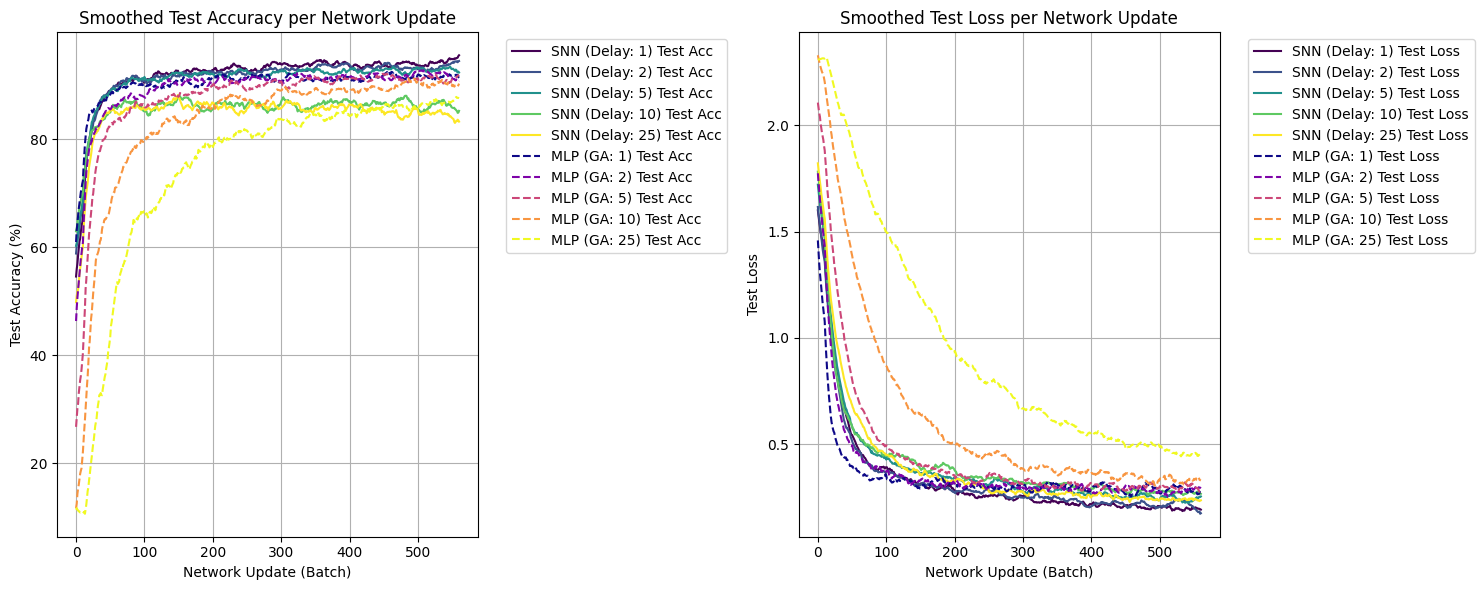

In [ ]:
import pandas as pd

# --- Calculate and display metrics for SNNs ---
snn_comparison_data = []
for interval, results in all_snn_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    snn_comparison_data.append({
        'Model': f'SNN (Delay: {interval})',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy': f'{auc_test_acc:.2f}'
    })

snn_comparison_df = pd.DataFrame(snn_comparison_data)
print("\n--- SNN Performance Comparison (Impact of Loss Aggregation Delay) ---")
print(snn_comparison_df.to_markdown(index=False))

# --- Calculate and display metrics for MLPs ---
mlp_comparison_data = []
for interval, results in all_mlp_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    mlp_comparison_data.append({
        'Model': f'MLP (GA: {interval})',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy': f'{auc_test_acc:.2f}'
    })

mlp_comparison_df = pd.DataFrame(mlp_comparison_data)
print("\n--- MLP Performance Comparison (Impact of Gradient Accumulation Steps) ---")
print(mlp_comparison_df.to_markdown(index=False))

# --- Unified Plotting (Optional, as requested in context summary) ---
# This section prepares data for a combined plot if needed, but the primary request was metrics.
# For now, we focus on the requested metrics in table format.

plt.figure(figsize=(15, 6))

# Plotting Accuracy
plt.subplot(1, 2, 1)

# SNNs
snn_colors = plt.cm.viridis(np.linspace(0, 1, len(loss_intervals)))
for i, interval in enumerate(loss_intervals):
    results = all_snn_results[interval]
    plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'SNN (Delay: {interval}) Test Acc', color=snn_colors[i], linestyle='-')

# MLPs
mlp_colors = plt.cm.plasma(np.linspace(0, 1, len(gradient_accumulation_intervals)))
for i, interval in enumerate(gradient_accumulation_intervals):
    results = all_mlp_results[interval]
    plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'MLP (GA: {interval}) Test Acc', color=mlp_colors[i], linestyle='--')

plt.title('Smoothed Test Accuracy per Network Update')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)

# SNNs
for i, interval in enumerate(loss_intervals):
    results = all_snn_results[interval]
    plt.plot(results['smoothed_test_loss'], label=f'SNN (Delay: {interval}) Test Loss', color=snn_colors[i], linestyle='-')

# MLPs
for i, interval in enumerate(gradient_accumulation_intervals):
    results = all_mlp_results[interval]
    plt.plot(results['smoothed_test_loss'], label=f'MLP (GA: {interval}) Test Loss', color=mlp_colors[i], linestyle='--')

plt.title('Smoothed Test Loss per Network Update')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# --- Calculate and display metrics for SNNs ---
snn_comparison_data = []
for interval, results in all_snn_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    num_batches = len(results['smoothed_test_acc']) # Get the number of batches
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    snn_comparison_data.append({
        'Model': f'SNN (Delay: {interval})',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch': f'{avg_test_acc_per_batch:.2f}%'
    })

snn_comparison_df = pd.DataFrame(snn_comparison_data)
print("\n--- SNN Performance Comparison (Impact of Loss Aggregation Delay) ---")
print(snn_comparison_df.to_markdown(index=False))

# --- Calculate and display metrics for MLPs ---
mlp_comparison_data = []
for interval, results in all_mlp_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    num_batches = len(results['smoothed_test_acc']) # Get the number of batches
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    mlp_comparison_data.append({
        'Model': f'MLP (GA: {interval})',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch': f'{avg_test_acc_per_batch:.2f}%'
    })

mlp_comparison_df = pd.DataFrame(mlp_comparison_data)
print("\n--- MLP Performance Comparison (Impact of Gradient Accumulation Steps) ---")
print(mlp_comparison_df.to_markdown(index=False))


--- SNN Performance Comparison (Impact of Loss Aggregation Delay) ---
| Model           | Final Test Accuracy   |   AUC Test Accuracy (Sum) | Average Test Accuracy per Batch   |
|:----------------|:----------------------|--------------------------:|:----------------------------------|
| SNN (Delay: 1)  | 0.96%                 |                    515.01 | 0.92%                             |
| SNN (Delay: 2)  | 0.94%                 |                    512.51 | 0.91%                             |
| SNN (Delay: 5)  | 0.92%                 |                    510.44 | 0.91%                             |
| SNN (Delay: 10) | 0.85%                 |                    480.42 | 0.86%                             |
| SNN (Delay: 25) | 0.83%                 |                    474.51 | 0.85%                             |

--- MLP Performance Comparison (Impact of Gradient Accumulation Steps) ---
| Model        | Final Test Accuracy   |   AUC Test Accuracy (Sum) | Average Test Accuracy per Ba

Starting training for SNN (Prob: 75%) (Prob Loss: 0.75)...
SNN (Prob: 75%) Epoch 0, Iteration 0
SNN (Prob: 75%) Train Set Loss: 1.62
SNN (Prob: 75%) Test Set Loss: 1.93
SNN (Prob: 75%) Train set accuracy for a single minibatch: 25.00%
SNN (Prob: 75%) Test set accuracy for a single minibatch: 12.50%


SNN (Prob: 75%) Epoch 0, Iteration 50
SNN (Prob: 75%) Train Set Loss: 0.35
SNN (Prob: 75%) Test Set Loss: 0.55
SNN (Prob: 75%) Train set accuracy for a single minibatch: 89.06%
SNN (Prob: 75%) Test set accuracy for a single minibatch: 82.81%


SNN (Prob: 75%) Epoch 0, Iteration 100
SNN (Prob: 75%) Train Set Loss: 0.35
SNN (Prob: 75%) Test Set Loss: 0.22
SNN (Prob: 75%) Train set accuracy for a single minibatch: 88.28%
SNN (Prob: 75%) Test set accuracy for a single minibatch: 94.53%


SNN (Prob: 75%) Epoch 0, Iteration 150
SNN (Prob: 75%) Train Set Loss: 0.45
SNN (Prob: 75%) Test Set Loss: 0.29
SNN (Prob: 75%) Train set accuracy for a single minibatch: 89.84%
SNN (Prob: 75%) Test set accura

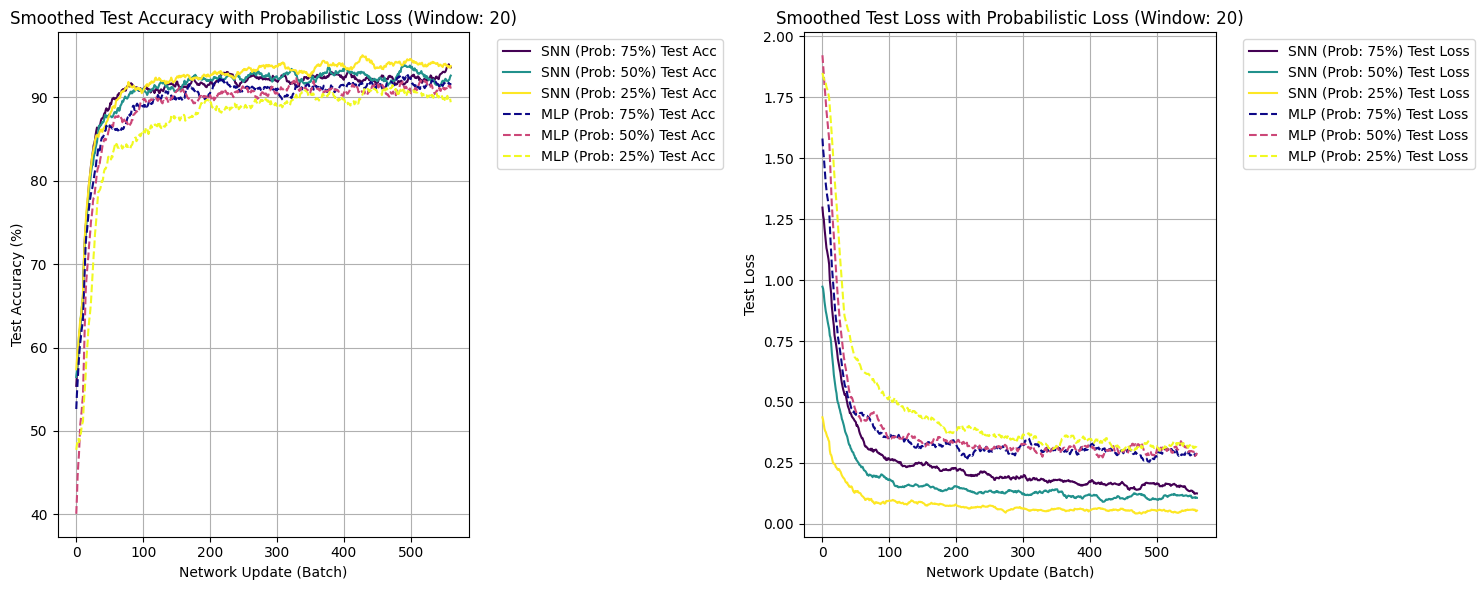


--- SNN Performance Comparison (Impact of Probabilistic Loss) ---
| Model           | Final Test Accuracy   |   AUC Test Accuracy (Sum) | Average Test Accuracy per Batch   |
|:----------------|:----------------------|--------------------------:|:----------------------------------|
| SNN (Prob: 75%) | 0.94%                 |                    509.14 | 0.91%                             |
| SNN (Prob: 50%) | 0.93%                 |                    509.48 | 0.91%                             |
| SNN (Prob: 25%) | 0.94%                 |                    514.65 | 0.92%                             |

--- MLP Performance Comparison (Impact of Probabilistic Loss) ---
| Model           | Final Test Accuracy   |   AUC Test Accuracy (Sum) | Average Test Accuracy per Batch   |
|:----------------|:----------------------|--------------------------:|:----------------------------------|
| MLP (Prob: 75%) | 0.92%                 |                    501.43 | 0.89%                             |
| 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random # Need to import random
import pandas as pd # Ensure pandas is imported for dataframe output

# Define the probability levels for loss counting
loss_probabilities = [0.75, 0.5, 0.25]

# --- Modified SNN Training Function for Probabilistic Loss ---
def train_snn_probabilistic_variant(snn_model, snn_optimizer, train_loader, test_loader,
                                    num_epochs, num_steps, loss_probability, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    dtype = torch.float # Ensure dtype is defined

    print(f"Starting training for {model_name} (Prob Loss: {loss_probability})...")

    # Helper function to print accuracy for a single batch
    def print_batch_accuracy_variant(data, targets, train=False):
        output, _ = snn_model(data.view(config.BATCH_SIZE, -1))
        _, idx = output.sum(dim=0).max(1)
        acc = np.mean((targets == idx).detach().cpu().numpy())
        # if train:
        #     print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        # else:
        #     print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    # Helper function to print training progress
    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        # print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        # print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        # print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        # print_batch_accuracy_variant(data, targets, train=True)
        # print_batch_accuracy_variant(test_data, test_targets, train=False)
        # print("\n")
        pass # Reduced printing frequency as requested

    # Outer training loop
    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        # Minibatch training loop
        for data, targets in train_batch_iter:
            data = data.to(device)
            targets = targets.to(device)

            snn_model.train()
            spk_rec, mem_rec = snn_model(data.view(config.BATCH_SIZE, -1))

            loss_val_accumulated = torch.zeros((1), dtype=dtype, device=device)
            timesteps_contributing_to_loss = 0

            for step in range(num_steps):
                if random.random() < loss_probability:
                    current_step_loss = loss(mem_rec[step], targets)
                    loss_val_accumulated += current_step_loss
                    timesteps_contributing_to_loss += 1

            # Store the average actual loss for plotting (even if 0)
            loss_val_for_hist = loss_val_accumulated / num_steps if num_steps > 0 else torch.zeros((1), dtype=dtype, device=device)
            loss_hist.append(loss_val_for_hist.item())

            if timesteps_contributing_to_loss > 0:
                loss_val_for_backward = loss_val_accumulated / timesteps_contributing_to_loss # Normalize by actual contributing timesteps
                snn_optimizer.zero_grad()
                loss_val_for_backward.backward()
                snn_optimizer.step()
            else:
                # If no loss was counted for this batch, effectively no gradient update happens
                pass

            # Calculate and store training accuracy
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation (within training loop)
            with torch.no_grad():
                snn_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_spk, test_mem = snn_model(test_data.view(config.BATCH_SIZE, -1))

                test_loss_accumulated = torch.zeros((1), dtype=dtype, device=device)
                test_timesteps_contributing_to_loss = 0
                for step in range(num_steps):
                    # For test loss reporting, we should ideally compute the full loss
                    # to get a true measure of performance, not probabilistically filtered.
                    # However, to be consistent with the *training* notion of 'counted or not',
                    # we'll apply the probability here as well for reporting.
                    if random.random() < loss_probability:
                        test_loss_accumulated += loss(test_mem[step], test_targets)
                        test_timesteps_contributing_to_loss += 1

                test_loss_for_hist = test_loss_accumulated / num_steps if num_steps > 0 else torch.zeros((1), dtype=dtype, device=device)
                test_loss_hist.append(test_loss_for_hist.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                if counter % 50 == 0: # Still print periodically, but train_printer_variant is now mostly muted
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter +=1
    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Modified MLP Training Function for Probabilistic Loss ---
def train_mlp_probabilistic_variant(mlp_model, mlp_optimizer, train_loader, test_loader,
                                    num_epochs, loss_probability, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    criterion_mlp = nn.CrossEntropyLoss()

    print(f"Starting training for {model_name} (Prob Loss: {loss_probability})..."

    def print_batch_accuracy_variant(data, targets, train=False):
        mlp_model.eval()
        y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
        predicted_labels = torch.argmax(y_pred, dim=1)
        acc = (targets == predicted_labels).float().mean().item()
        # if train:
        #     print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        # else:
        #     print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        # print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        # print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        # print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        # print_batch_accuracy_variant(data, targets, train=True)
        # print_batch_accuracy_variant(test_data, test_targets, train=False)
        # print("\n")
        pass # Reduced printing frequency as requested

    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        # Zero gradients at the start of each epoch to ensure a clean slate for accumulation attempts
        mlp_optimizer.zero_grad()

        for batch_idx, (data, targets) in enumerate(train_batch_iter):
            data = data.to(device)
            targets = targets.to(device)

            mlp_model.train()
            y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
            loss_val = criterion_mlp(y_pred, targets)

            # Decide whether to count this loss for backward pass
            if random.random() < loss_probability:
                loss_val.backward() # Accumulate gradients
                mlp_optimizer.step() # Apply accumulated gradients
                mlp_optimizer.zero_grad() # Clear gradients for the next accumulation cycle
            else:
                # If loss is not counted, no backward pass for this batch, but clear gradients anyway
                # to avoid lingering gradients from a potentially *very* old backward call if `step()`
                # hasn't happened in a while due to low probability. This is a subtle interaction
                # and this approach ensures each batch either contributes a gradient and steps,
                # or contributes nothing and resets for the next.
                mlp_optimizer.zero_grad()
                pass

            # Store the actual calculated loss for plotting, regardless of whether it was used for backprop
            loss_hist.append(loss_val.item())

            # Calculate and store training accuracy (per batch)
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation (run for every training batch for consistent plotting)
            with torch.no_grad():
                mlp_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_y_pred = mlp_model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion_mlp(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                if counter % 50 == 0: # Still print periodically, but train_printer_variant is now mostly muted
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter += 1

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Run experiments for SNN ---
all_snn_prob_results = {}
num_steps = config.NUM_SNN_TIMESTEPS # For SNN training

for prob in loss_probabilities:
    # Create a new SNN model instance and its optimizer for each variant
    current_snn_net = SNN_MLP().to(device)
    current_snn_optimizer = torch.optim.Adam(current_snn_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    model_name = f"SNN (Prob: {prob*100:.0f}%)"
    loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
        train_snn_probabilistic_variant(current_snn_net, current_snn_optimizer, train_loader, test_loader,
                                        config.NUM_EPOCHS, num_steps, prob, model_name)

    all_snn_prob_results[prob] = {
        'train_acc': train_acc_hist,
        'test_acc': test_acc_hist,
        'train_loss': loss_hist,
        'test_loss': test_loss_hist
    }

# --- Run experiments for MLP ---
all_mlp_prob_results = {}

for prob in loss_probabilities:
    # Create a new MLP model instance and its optimizer for each variant
    current_mlp_net = MultiLayerPerceptron(
        num_hidden =  config.NUM_HIDDEN,
        activation_type = "leaky",
        bias = config.BIAS,
        ).to(device)
    current_mlp_optimizer = torch.optim.Adam(current_mlp_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    model_name = f"MLP (Prob: {prob*100:.0f}%)"
    loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
        train_mlp_probabilistic_variant(current_mlp_net, current_mlp_optimizer, train_loader, test_loader,
                                        config.NUM_EPOCHS, prob, model_name)

    all_mlp_prob_results[prob] = {
        'train_acc': train_acc_hist,
        'test_acc': test_acc_hist,
        'train_loss': loss_hist,
        'test_loss': test_loss_hist
    }

# --- Apply smoothing to all collected histories ---
SMOOTHING_WINDOW = 20

for prob, histories in all_snn_prob_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

for prob, histories in all_mlp_prob_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)


# --- Plotting the smoothed results ---
plt.figure(figsize=(15, 6))

# Plotting Accuracy for SNNs
plt.subplot(1, 2, 1)
snn_colors = plt.cm.viridis(np.linspace(0, 1, len(loss_probabilities)))
for i, prob in enumerate(loss_probabilities):
    results = all_snn_prob_results[prob]
    plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'SNN (Prob: {prob*100:.0f}%) Test Acc', color=snn_colors[i], linestyle='-')

# Plotting Accuracy for MLPs
mlp_colors = plt.cm.plasma(np.linspace(0, 1, len(loss_probabilities)))
for i, prob in enumerate(loss_probabilities):
    results = all_mlp_prob_results[prob]
    plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'MLP (Prob: {prob*100:.0f}%) Test Acc', color=mlp_colors[i], linestyle='--')

plt.title(f'Smoothed Test Accuracy with Probabilistic Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Plotting Loss for SNNs
plt.subplot(1, 2, 2)
for i, prob in enumerate(loss_probabilities):
    results = all_snn_prob_results[prob]
    plt.plot(results['smoothed_test_loss'], label=f'SNN (Prob: {prob*100:.0f}%) Test Loss', color=snn_colors[i], linestyle='-')

# Plotting Loss for MLPs
for i, prob in enumerate(loss_probabilities):
    results = all_mlp_prob_results[prob]
    plt.plot(results['smoothed_test_loss'], label=f'MLP (Prob: {prob*100:.0f}%) Test Loss', color=mlp_colors[i], linestyle='--')

plt.title(f'Smoothed Test Loss with Probabilistic Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


# --- Display comparative metrics (text tables) ---
print("\n--- SNN Performance Comparison (Impact of Probabilistic Loss) ---")
snn_prob_comparison_data = []
for prob, results in all_snn_prob_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    snn_prob_comparison_data.append({
        'Model': f'SNN (Prob: {prob*100:.0f}%)',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch': f'{avg_test_acc_per_batch:.2f}%'
    })

snn_prob_comparison_df = pd.DataFrame(snn_prob_comparison_data)
print(snn_prob_comparison_df.to_markdown(index=False))

print("\n--- MLP Performance Comparison (Impact of Probabilistic Loss) ---")
mlp_prob_comparison_data = []
for prob, results in all_mlp_prob_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    mlp_prob_comparison_data.append({
        'Model': f'MLP (Prob: {prob*100:.0f}%)',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch': f'{avg_test_acc_per_batch:.2f}%'
    })

mlp_prob_comparison_df = pd.DataFrame(mlp_prob_comparison_data)
print(mlp_prob_comparison_df.to_markdown(index=False))


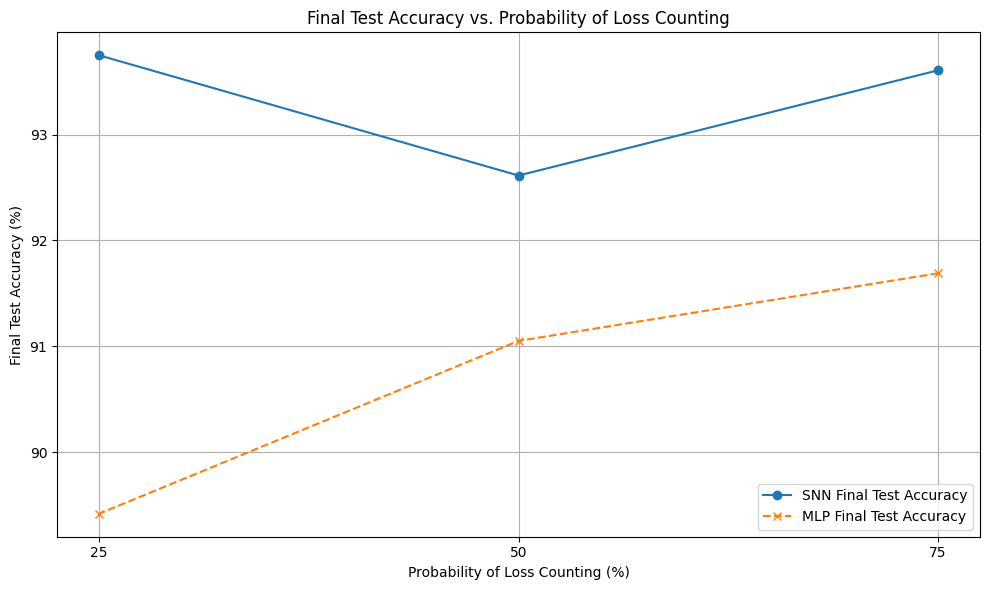

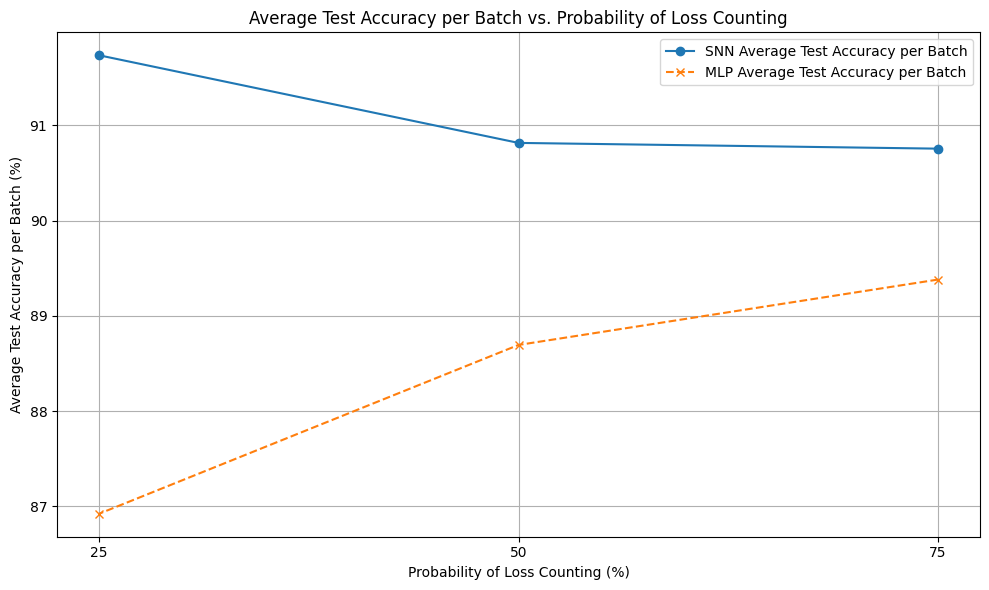

In [ ]:
# Extract data for plotting
prob_values = np.array(loss_probabilities) # Already defined as [0.75, 0.5, 0.25]

snn_final_accs = [all_snn_prob_results[p]['smoothed_test_acc'][-1] * 100 if all_snn_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]
snn_avg_acc_per_batch = [sum(all_snn_prob_results[p]['smoothed_test_acc']) / len(all_snn_prob_results[p]['smoothed_test_acc']) * 100 if all_snn_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]

mlp_final_accs = [all_mlp_prob_results[p]['smoothed_test_acc'][-1] * 100 if all_mlp_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]
mlp_avg_acc_per_batch = [sum(all_mlp_prob_results[p]['smoothed_test_acc']) / len(all_mlp_prob_results[p]['smoothed_test_acc']) * 100 if all_mlp_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]


# --- Plotting Final Test Accuracy vs. Probability ---
plt.figure(figsize=(10, 6))
plt.plot(prob_values * 100, snn_final_accs, marker='o', linestyle='-', label='SNN Final Test Accuracy')
plt.plot(prob_values * 100, mlp_final_accs, marker='x', linestyle='--', label='MLP Final Test Accuracy')

plt.title('Final Test Accuracy vs. Probability of Loss Counting')
plt.xlabel('Probability of Loss Counting (%)')
plt.ylabel('Final Test Accuracy (%)')
plt.xticks(prob_values * 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plotting Average Test Accuracy per Batch vs. Probability ---
plt.figure(figsize=(10, 6))
plt.plot(prob_values * 100, snn_avg_acc_per_batch, marker='o', linestyle='-', label='SNN Average Test Accuracy per Batch')
plt.plot(prob_values * 100, mlp_avg_acc_per_batch, marker='x', linestyle='--', label='MLP Average Test Accuracy per Batch')

plt.title('Average Test Accuracy per Batch vs. Probability of Loss Counting')
plt.xlabel('Probability of Loss Counting (%)')
plt.ylabel('Average Test Accuracy per Batch (%)')
plt.xticks(prob_values * 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Starting training for SNN (Prob: 75%) (Prob Loss: 0.75)...
Starting training for SNN (Prob: 50%) (Prob Loss: 0.5)...
Starting training for SNN (Prob: 25%) (Prob Loss: 0.25)...
Starting training for SNN (Prob: 5%) (Prob Loss: 0.05)...
Starting training for MLP (Prob: 75%) (Prob Loss: 0.75)...
Starting training for MLP (Prob: 50%) (Prob Loss: 0.5)...
Starting training for MLP (Prob: 25%) (Prob Loss: 0.25)...
Starting training for MLP (Prob: 5%) (Prob Loss: 0.05)...


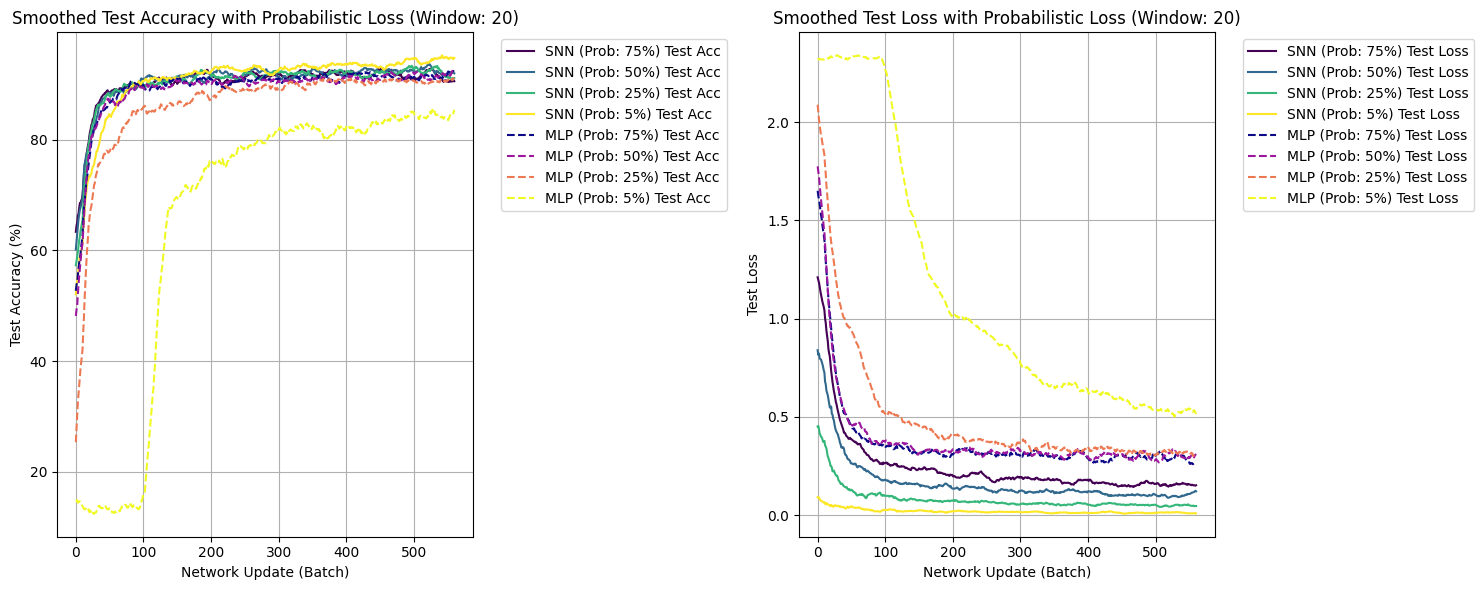


--- SNN Performance Comparison (Impact of Probabilistic Loss) ---
| Model           | Final Test Accuracy   |   AUC Test Accuracy (Sum) | Average Test Accuracy per Batch   |
|:----------------|:----------------------|--------------------------:|:----------------------------------|
| SNN (Prob: 75%) | 0.91%                 |                    506.49 | 0.90%                             |
| SNN (Prob: 50%) | 0.92%                 |                    507.73 | 0.91%                             |
| SNN (Prob: 25%) | 0.91%                 |                    506.4  | 0.90%                             |
| SNN (Prob: 5%)  | 0.95%                 |                    508.87 | 0.91%                             |

--- MLP Performance Comparison (Impact of Probabilistic Loss) ---
| Model           | Final Test Accuracy   |   AUC Test Accuracy (Sum) | Average Test Accuracy per Batch   |
|:----------------|:----------------------|--------------------------:|:----------------------------------|
| 

In [ ]:
#@title train
import numpy as np
import matplotlib.pyplot as plt
import torch
import random # Need to import random
import pandas as pd # Ensure pandas is imported for dataframe output

# Define the probability levels for loss counting
loss_probabilities = [0.75, 0.5, 0.25, 0.05]

# --- Modified SNN Training Function for Probabilistic Loss ---
def train_snn_probabilistic_variant(snn_model, snn_optimizer, train_loader, test_loader,
                                    num_epochs, num_steps, loss_probability, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    dtype = torch.float # Ensure dtype is defined

    print(f"Starting training for {model_name} (Prob Loss: {loss_probability})...")

    # Helper function to print accuracy for a single batch
    def print_batch_accuracy_variant(data, targets, train=False):
        output, _ = snn_model(data.view(config.BATCH_SIZE, -1))
        _, idx = output.sum(dim=0).max(1)
        acc = np.mean((targets == idx).detach().cpu().numpy())
        # if train:
        #     print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        # else:
        #     print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    # Helper function to print training progress
    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        # print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        # print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        # print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        # print_batch_accuracy_variant(data, targets, train=True)
        # print_batch_accuracy_variant(test_data, test_targets, train=False)
        # print("\n")
        pass # Reduced printing frequency as requested

    # Outer training loop
    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        # Minibatch training loop
        for data, targets in train_batch_iter:
            data = data.to(device)
            targets = targets.to(device)

            snn_model.train()
            spk_rec, mem_rec = snn_model(data.view(config.BATCH_SIZE, -1))

            loss_val_accumulated = torch.zeros((1), dtype=dtype, device=device)
            timesteps_contributing_to_loss = 0

            for step in range(num_steps):
                if random.random() < loss_probability:
                    current_step_loss = loss(mem_rec[step], targets)
                    loss_val_accumulated += current_step_loss
                    timesteps_contributing_to_loss += 1

            # Store the average actual loss for plotting (even if 0)
            loss_val_for_hist = loss_val_accumulated / num_steps if num_steps > 0 else torch.zeros((1), dtype=dtype, device=device)
            loss_hist.append(loss_val_for_hist.item())

            if timesteps_contributing_to_loss > 0:
                loss_val_for_backward = loss_val_accumulated / timesteps_contributing_to_loss # Normalize by actual contributing timesteps
                snn_optimizer.zero_grad()
                loss_val_for_backward.backward()
                snn_optimizer.step()
            else:
                # If no loss was counted for this batch, effectively no gradient update happens
                pass

            # Calculate and store training accuracy
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation (within training loop)
            with torch.no_grad():
                snn_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_spk, test_mem = snn_model(test_data.view(config.BATCH_SIZE, -1))

                test_loss_accumulated = torch.zeros((1), dtype=dtype, device=device)
                test_timesteps_contributing_to_loss = 0
                for step in range(num_steps):
                    # For test loss reporting, we should ideally compute the full loss
                    # to get a true measure of performance, not probabilistically filtered.
                    # However, to be consistent with the *training* notion of 'counted or not',
                    # we'll apply the probability here as well for reporting.
                    if random.random() < loss_probability:
                        test_loss_accumulated += loss(test_mem[step], test_targets)
                        test_timesteps_contributing_to_loss += 1

                test_loss_for_hist = test_loss_accumulated / num_steps if num_steps > 0 else torch.zeros((1), dtype=dtype, device=device)
                test_loss_hist.append(test_loss_for_hist.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                if counter % 50 == 0: # Still print periodically, but train_printer_variant is now mostly muted
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter +=1
    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Modified MLP Training Function for Probabilistic Loss ---
def train_mlp_probabilistic_variant(mlp_model, mlp_optimizer, train_loader, test_loader,
                                    num_epochs, loss_probability, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    criterion_mlp = nn.CrossEntropyLoss()

    print(f"Starting training for {model_name} (Prob Loss: {loss_probability})...")

    def print_batch_accuracy_variant(data, targets, train=False):
        mlp_model.eval()
        y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
        predicted_labels = torch.argmax(y_pred, dim=1)
        acc = (targets == predicted_labels).float().mean().item()
        # if train:
        #     print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        # else:
        #     print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        # print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        # print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        # print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        # print_batch_accuracy_variant(data, targets, train=True)
        # print_batch_accuracy_variant(test_data, test_targets, train=False)
        # print("\n")
        pass # Reduced printing frequency as requested

    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        # Zero gradients at the start of each epoch to ensure a clean slate for accumulation attempts
        mlp_optimizer.zero_grad()

        for batch_idx, (data, targets) in enumerate(train_batch_iter):
            data = data.to(device)
            targets = targets.to(device)

            mlp_model.train()
            y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
            loss_val = criterion_mlp(y_pred, targets)

            # Decide whether to count this loss for backward pass
            if random.random() < loss_probability:
                loss_val.backward() # Accumulate gradients
                mlp_optimizer.step() # Apply accumulated gradients
                mlp_optimizer.zero_grad() # Clear gradients for the next accumulation cycle
            else:
                # If loss is not counted, no backward pass for this batch, but clear gradients anyway
                # to avoid lingering gradients from a potentially *very* old backward call if `step()`
                # hasn't happened in a while due to low probability. This is a subtle interaction
                # and this approach ensures each batch either contributes a gradient and steps,
                # or contributes nothing and resets for the next.
                mlp_optimizer.zero_grad()
                pass

            # Store the actual calculated loss for plotting, regardless of whether it was used for backprop
            loss_hist.append(loss_val.item())

            # Calculate and store training accuracy (per batch)
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation (run for every training batch for consistent plotting)
            with torch.no_grad():
                mlp_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_y_pred = mlp_model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion_mlp(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                if counter % 50 == 0: # Still print periodically, but train_printer_variant is now mostly muted
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter += 1

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Run experiments for SNN ---
all_snn_prob_results = {}
num_steps = config.NUM_SNN_TIMESTEPS # For SNN training

for prob in loss_probabilities:
    # Create a new SNN model instance and its optimizer for each variant
    current_snn_net = SNN_MLP().to(device)
    current_snn_optimizer = torch.optim.Adam(current_snn_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    model_name = f"SNN (Prob: {prob*100:.0f}%)"
    loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
        train_snn_probabilistic_variant(current_snn_net, current_snn_optimizer, train_loader, test_loader,
                                        config.NUM_EPOCHS, num_steps, prob, model_name)

    all_snn_prob_results[prob] = {
        'train_acc': train_acc_hist,
        'test_acc': test_acc_hist,
        'train_loss': loss_hist,
        'test_loss': test_loss_hist
    }

# --- Run experiments for MLP ---
all_mlp_prob_results = {}

for prob in loss_probabilities:
    # Create a new MLP model instance and its optimizer for each variant
    current_mlp_net = MultiLayerPerceptron(
        num_hidden =  config.NUM_HIDDEN,
        activation_type = "leaky",
        bias = config.BIAS,
        ).to(device)
    current_mlp_optimizer = torch.optim.Adam(current_mlp_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    model_name = f"MLP (Prob: {prob*100:.0f}%)"
    loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
        train_mlp_probabilistic_variant(current_mlp_net, current_mlp_optimizer, train_loader, test_loader,
                                        config.NUM_EPOCHS, prob, model_name)

    all_mlp_prob_results[prob] = {
        'train_acc': train_acc_hist,
        'test_acc': test_acc_hist,
        'train_loss': loss_hist,
        'test_loss': test_loss_hist
    }

# --- Apply smoothing to all collected histories ---
SMOOTHING_WINDOW = 20

for prob, histories in all_snn_prob_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

for prob, histories in all_mlp_prob_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)


# --- Plotting the smoothed results ---
plt.figure(figsize=(15, 6))

# Plotting Accuracy for SNNs
plt.subplot(1, 2, 1)
snn_colors = plt.cm.viridis(np.linspace(0, 1, len(loss_probabilities)))
for i, prob in enumerate(loss_probabilities):
    results = all_snn_prob_results[prob]
    plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'SNN (Prob: {prob*100:.0f}%) Test Acc', color=snn_colors[i], linestyle='-')

# Plotting Accuracy for MLPs
mlp_colors = plt.cm.plasma(np.linspace(0, 1, len(loss_probabilities)))
for i, prob in enumerate(loss_probabilities):
    results = all_mlp_prob_results[prob]
    plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'MLP (Prob: {prob*100:.0f}%) Test Acc', color=mlp_colors[i], linestyle='--')

plt.title(f'Smoothed Test Accuracy with Probabilistic Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Plotting Loss for SNNs
plt.subplot(1, 2, 2)
for i, prob in enumerate(loss_probabilities):
    results = all_snn_prob_results[prob]
    plt.plot(results['smoothed_test_loss'], label=f'SNN (Prob: {prob*100:.0f}%) Test Loss', color=snn_colors[i], linestyle='-')

# Plotting Loss for MLPs
for i, prob in enumerate(loss_probabilities):
    results = all_mlp_prob_results[prob]
    plt.plot(results['smoothed_test_loss'], label=f'MLP (Prob: {prob*100:.0f}%) Test Loss', color=mlp_colors[i], linestyle='--')

plt.title(f'Smoothed Test Loss with Probabilistic Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


# --- Display comparative metrics (text tables) ---
print("\n--- SNN Performance Comparison (Impact of Probabilistic Loss) ---")
snn_prob_comparison_data = []
for prob, results in all_snn_prob_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    snn_prob_comparison_data.append({
        'Model': f'SNN (Prob: {prob*100:.0f}%)',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch': f'{avg_test_acc_per_batch:.2f}%'
    })

snn_prob_comparison_df = pd.DataFrame(snn_prob_comparison_data)
print(snn_prob_comparison_df.to_markdown(index=False))

print("\n--- MLP Performance Comparison (Impact of Probabilistic Loss) ---")
mlp_prob_comparison_data = []
for prob, results in all_mlp_prob_results.items():
    final_test_acc = results['smoothed_test_acc'][-1] if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc'])
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    mlp_prob_comparison_data.append({
        'Model': f'MLP (Prob: {prob*100:.0f}%)',
        'Final Test Accuracy': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch': f'{avg_test_acc_per_batch:.2f}%'
    })

mlp_prob_comparison_df = pd.DataFrame(mlp_prob_comparison_data)
print(mlp_prob_comparison_df.to_markdown(index=False))


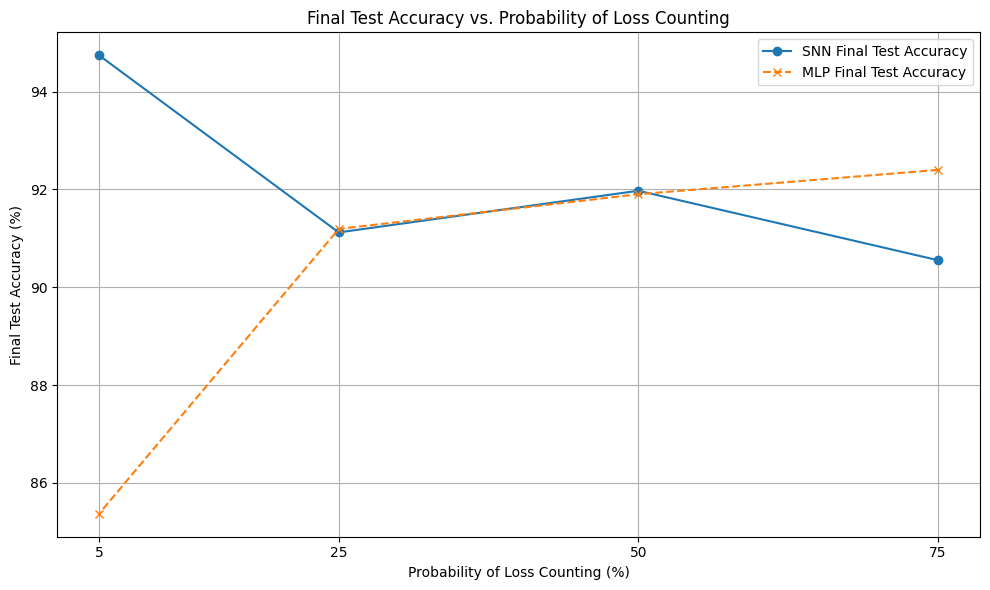

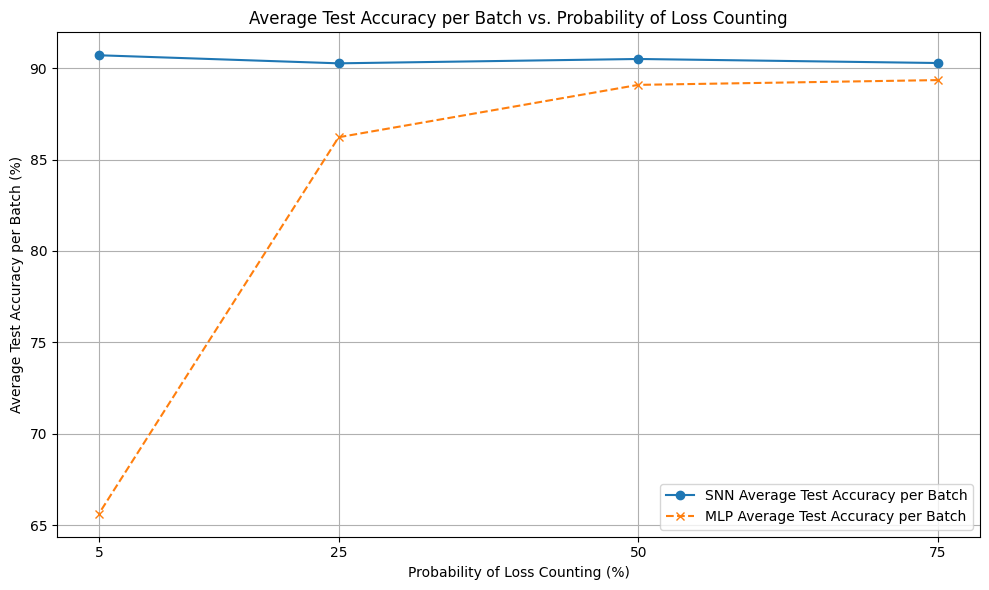

In [ ]:
# Extract data for plotting
prob_values = np.array(loss_probabilities) # Already defined as [0.75, 0.5, 0.25]

snn_final_accs = [all_snn_prob_results[p]['smoothed_test_acc'][-1] * 100 if all_snn_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]
snn_avg_acc_per_batch = [sum(all_snn_prob_results[p]['smoothed_test_acc']) / len(all_snn_prob_results[p]['smoothed_test_acc']) * 100 if all_snn_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]

mlp_final_accs = [all_mlp_prob_results[p]['smoothed_test_acc'][-1] * 100 if all_mlp_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]
mlp_avg_acc_per_batch = [sum(all_mlp_prob_results[p]['smoothed_test_acc']) / len(all_mlp_prob_results[p]['smoothed_test_acc']) * 100 if all_mlp_prob_results[p]['smoothed_test_acc'] else 0 for p in prob_values]


# --- Plotting Final Test Accuracy vs. Probability ---
plt.figure(figsize=(10, 6))
plt.plot(prob_values * 100, snn_final_accs, marker='o', linestyle='-', label='SNN Final Test Accuracy')
plt.plot(prob_values * 100, mlp_final_accs, marker='x', linestyle='--', label='MLP Final Test Accuracy')

plt.title('Final Test Accuracy vs. Probability of Loss Counting')
plt.xlabel('Probability of Loss Counting (%)')
plt.ylabel('Final Test Accuracy (%)')
plt.xticks(prob_values * 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plotting Average Test Accuracy per Batch vs. Probability ---
plt.figure(figsize=(10, 6))
plt.plot(prob_values * 100, snn_avg_acc_per_batch, marker='o', linestyle='-', label='SNN Average Test Accuracy per Batch')
plt.plot(prob_values * 100, mlp_avg_acc_per_batch, marker='x', linestyle='--', label='MLP Average Test Accuracy per Batch')

plt.title('Average Test Accuracy per Batch vs. Probability of Loss Counting')
plt.xlabel('Probability of Loss Counting (%)')
plt.ylabel('Average Test Accuracy per Batch (%)')
plt.xticks(prob_values * 100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Task
The goal is to implement and compare the performance of Spiking Neural Networks (SNNs) and Multilayer Perceptrons (MLPs) when training with probabilistic loss counting and fixed delay for applying updates. This involves modifying existing training functions to incorporate these new mechanisms, explaining the combined approach, and then evaluating their impact on model performance.

## Implement SNN probabilistic and delayed training

### Subtask:
Define a new SNN training function that combines probabilistic loss counting with a fixed delay interval for applying updates.


**Reasoning**:
I need to define the `train_snn_prob_delayed_variant` function, which combines probabilistic loss counting and delayed loss aggregation per timestep for SNNs. This function will be similar to previous SNN training functions but will incorporate both conditions (random probability and aggregation interval check) for including a timestep's loss in the backward pass. After defining the function, I will perform the requested experiments by iterating through `loss_probabilities` and `loss_aggregation_intervals`.



Starting training for SNN (Prob: 75%, Delay: 1) (Prob: 0.75, Delay: 1)...
Starting training for SNN (Prob: 75%, Delay: 2) (Prob: 0.75, Delay: 2)...
Starting training for SNN (Prob: 75%, Delay: 5) (Prob: 0.75, Delay: 5)...
Starting training for SNN (Prob: 75%, Delay: 10) (Prob: 0.75, Delay: 10)...
Starting training for SNN (Prob: 75%, Delay: 25) (Prob: 0.75, Delay: 25)...
Starting training for SNN (Prob: 50%, Delay: 1) (Prob: 0.5, Delay: 1)...
Starting training for SNN (Prob: 50%, Delay: 2) (Prob: 0.5, Delay: 2)...
Starting training for SNN (Prob: 50%, Delay: 5) (Prob: 0.5, Delay: 5)...
Starting training for SNN (Prob: 50%, Delay: 10) (Prob: 0.5, Delay: 10)...
Starting training for SNN (Prob: 50%, Delay: 25) (Prob: 0.5, Delay: 25)...
Starting training for SNN (Prob: 25%, Delay: 1) (Prob: 0.25, Delay: 1)...
Starting training for SNN (Prob: 25%, Delay: 2) (Prob: 0.25, Delay: 2)...
Starting training for SNN (Prob: 25%, Delay: 5) (Prob: 0.25, Delay: 5)...
Starting training for SNN (Prob: 25

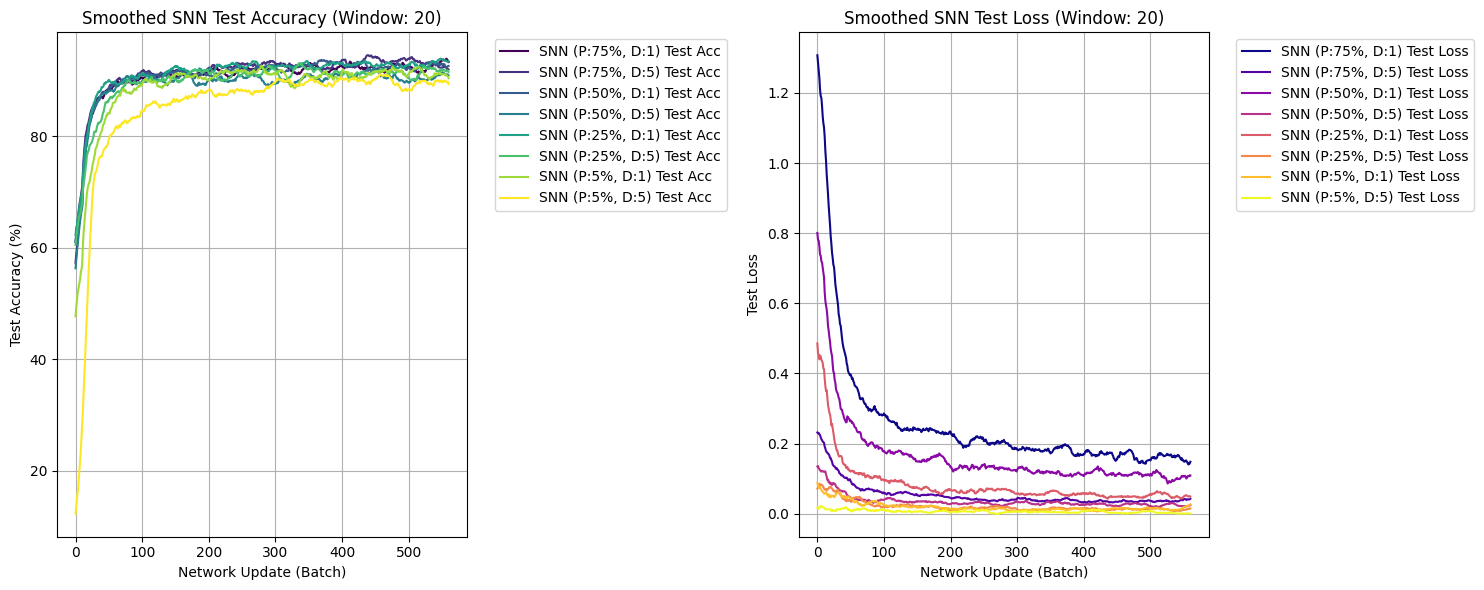

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import pandas as pd

# Define the probability levels for loss counting
loss_probabilities = [0.75, 0.5, 0.25, 0.05]
# Define the different loss aggregation intervals to test
loss_aggregation_intervals = [1, 2, 5, 10, 25]

# --- Combined SNN Training Function for Probabilistic Loss and Delayed Aggregation ---
def train_snn_prob_delayed_variant(snn_model, snn_optimizer, train_loader, test_loader,
                                   num_epochs, num_steps, loss_probability, loss_aggregation_interval, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    dtype = torch.float # Ensure dtype is defined

    print(f"Starting training for {model_name} (Prob: {loss_probability}, Delay: {loss_aggregation_interval})...")

    # Helper function to print accuracy for a single batch (muted for brevity)
    def print_batch_accuracy_variant(data, targets, train=False):
        pass

    # Helper function to print training progress (muted for brevity)
    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        pass

    # Outer training loop
    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        # Minibatch training loop
        for data, targets in train_batch_iter:
            data = data.to(device)
            targets = targets.to(device)

            snn_model.train()
            spk_rec, mem_rec = snn_model(data.view(config.BATCH_SIZE, -1))

            loss_val_accumulated = torch.zeros((1), dtype=dtype, device=device)
            actual_contributing_timesteps = 0

            for step in range(num_steps):
                # Apply probabilistic counting AND delay interval for loss aggregation
                if random.random() < loss_probability and (step % loss_aggregation_interval) == 0:
                    current_step_loss = loss(mem_rec[step], targets)
                    loss_val_accumulated += current_step_loss
                    actual_contributing_timesteps += 1

            # Store the average actual loss for plotting (even if 0)
            # We normalize by total timesteps for consistent plotting scale
            loss_val_for_hist = loss_val_accumulated / num_steps if num_steps > 0 else torch.zeros((1), dtype=dtype, device=device)
            loss_hist.append(loss_val_for_hist.item())

            # Gradient calculation + weight update
            snn_optimizer.zero_grad()
            if actual_contributing_timesteps > 0:
                # Normalize by actual contributing timesteps for correct gradient scaling
                loss_val_for_backward = loss_val_accumulated / actual_contributing_timesteps
                loss_val_for_backward.backward()
                snn_optimizer.step()
            else:
                # If no loss was counted for this batch, effectively no gradient update happens
                pass

            # Calculate and store training accuracy
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation (within training loop, run for every training batch for consistent plotting)
            with torch.no_grad():
                snn_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_spk, test_mem = snn_model(test_data.view(config.BATCH_SIZE, -1))

                test_loss_accumulated = torch.zeros((1), dtype=dtype, device=device)
                test_actual_contributing_timesteps = 0
                for step in range(num_steps):
                    # For test loss reporting, apply both probability and delay for consistency with training
                    if random.random() < loss_probability and (step % loss_aggregation_interval) == 0:
                        test_loss_accumulated += loss(test_mem[step], test_targets)
                        test_actual_contributing_timesteps += 1

                test_loss_for_hist = test_loss_accumulated / num_steps if num_steps > 0 else torch.zeros((1), dtype=dtype, device=device)
                test_loss_hist.append(test_loss_for_hist.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                # Print train/test loss/accuracy periodically (muted)
                if counter % 50 == 0:
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter +=1
    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Run experiments for SNN with combined probabilistic and delayed loss ---
all_snn_prob_delayed_results = {}
num_steps = config.NUM_SNN_TIMESTEPS # For SNN training

# Loop through each probability and each aggregation interval
for prob in loss_probabilities:
    for interval in loss_aggregation_intervals:
        # Create a new SNN model instance and its optimizer for each variant
        current_snn_net = SNN_MLP().to(device)
        current_snn_optimizer = torch.optim.Adam(current_snn_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

        model_name = f"SNN (Prob: {prob*100:.0f}%, Delay: {interval})"
        loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
            train_snn_prob_delayed_variant(current_snn_net, current_snn_optimizer, train_loader, test_loader,
                                          config.NUM_EPOCHS, num_steps, prob, interval, model_name)

        key = (prob, interval) # Use a tuple as key for the combination
        all_snn_prob_delayed_results[key] = {
            'train_acc': train_acc_hist,
            'test_acc': test_acc_hist,
            'train_loss': loss_hist,
            'test_loss': test_loss_hist
        }

# --- Apply smoothing to all collected histories ---
SMOOTHING_WINDOW = 20

for key, histories in all_snn_prob_delayed_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)


# --- Display comparative metrics (text tables) ---
print("\n--- SNN Performance Comparison (Probabilistic Loss & Delayed Aggregation) ---")
snn_prob_delayed_comparison_data = []
for key, results in all_snn_prob_delayed_results.items():
    prob, interval = key
    final_test_acc = results['smoothed_test_acc'][-1] * 100 if results['smoothed_test_acc'] else 0
    # Note: AUC is usually area under the curve, here it's sum of accuracies over batches
    auc_test_acc = sum(results['smoothed_test_acc']) * 100
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    snn_prob_delayed_comparison_data.append({
        'Model': f'SNN (Prob: {prob*100:.0f}%, Delay: {interval})',
        'Final Test Accuracy (%)': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum %)' : f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch:.2f}%'
    })

snn_prob_delayed_comparison_df = pd.DataFrame(snn_prob_delayed_comparison_data)
print(snn_prob_delayed_comparison_df.to_markdown(index=False))

# --- Plotting the smoothed results for a selected subset (e.g., Delay = 1 and 5) ---
plt.figure(figsize=(15, 6))

# Filter results for plotting (e.g., for Delay = 1 and Delay = 5 to keep plots readable)
plot_intervals = [1, 5]
plot_probs = loss_probabilities

filtered_snn_results_for_plot = { (p, i): all_snn_prob_delayed_results[(p, i)] for p in plot_probs for i in plot_intervals if (p,i) in all_snn_prob_delayed_results}

snn_colors_acc = plt.cm.viridis(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))

plt.subplot(1, 2, 1)
color_idx = 0
for prob in plot_probs:
    for interval in plot_intervals:
        key = (prob, interval)
        if key in filtered_snn_results_for_plot:
            results = filtered_snn_results_for_plot[key]
            plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'SNN (P:{prob*100:.0f}%, D:{interval}) Test Acc', color=snn_colors_acc[color_idx])
            color_idx += 1

plt.title(f'Smoothed SNN Test Accuracy (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
color_idx = 0
snn_colors_loss = plt.cm.plasma(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
for prob in plot_probs:
    for interval in plot_intervals:
        key = (prob, interval)
        if key in filtered_snn_results_for_plot:
            results = filtered_snn_results_for_plot[key]
            plt.plot(results['smoothed_test_loss'], label=f'SNN (P:{prob*100:.0f}%, D:{interval}) Test Loss', color=snn_colors_loss[color_idx])
            color_idx += 1

plt.title(f'Smoothed SNN Test Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

## Implement MLP probabilistic and delayed training

### Subtask:
Define a new MLP training function that combines probabilistic loss counting with gradient accumulation (delayed updates) for MLPs.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import pandas as pd

# Define the probability levels for loss counting
loss_probabilities = [0.75, 0.5, 0.25, 0.05]
# Define the different gradient accumulation intervals to test
gradient_accumulation_intervals = [1, 2, 5, 10, 25]

# --- Combined MLP Training Function for Probabilistic Loss and Delayed Gradient Accumulation ---
def train_mlp_prob_delayed_variant(mlp_model, mlp_optimizer, train_loader, test_loader,
                                   num_epochs, loss_probability, gradient_accumulation_steps, model_name):
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    criterion_mlp = nn.CrossEntropyLoss()

    print(f"Starting training for {model_name} (Prob: {loss_probability}, GA: {gradient_accumulation_steps})...")

    # Helper function to print accuracy for a single batch (muted for brevity)
    def print_batch_accuracy_variant(data, targets, train=False):
        pass

    # Helper function to print training progress (muted for brevity)
    def train_printer_variant(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        pass

    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        mlp_optimizer.zero_grad() # Zero gradients at the start of each accumulation cycle (or epoch for first batch)

        for batch_idx, (data, targets) in enumerate(train_batch_iter):
            data = data.to(device)
            targets = targets.to(device)

            mlp_model.train()
            y_pred = mlp_model(data.view(config.BATCH_SIZE, -1))
            loss_val = criterion_mlp(y_pred, targets)

            # Apply probabilistic counting for loss and accumulate gradients
            if random.random() < loss_probability:
                # Scale the loss by the accumulation steps for correct gradient averaging
                # This is crucial when combining probabilistic loss with gradient accumulation
                loss_val_for_backward = loss_val / gradient_accumulation_steps
                loss_val_for_backward.backward() # Accumulate gradients
            else:
                # If loss is not counted, don't perform backward pass for this batch
                pass

            # Store the original (unscaled) loss for plotting, regardless of whether it was used for backprop
            loss_hist.append(loss_val.item())

            # Calculate and store training accuracy (per batch)
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Perform optimizer step only after accumulation steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                mlp_optimizer.step() # Apply accumulated gradients
                mlp_optimizer.zero_grad() # Clear gradients for the next accumulation cycle

            # Test set evaluation (run for every training batch for consistent plotting)
            with torch.no_grad():
                mlp_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    test_loader_iter = iter(test_loader) # Reset if exhausted
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_y_pred = mlp_model(test_data.view(config.BATCH_SIZE, -1))

                # For test loss reporting, we should ideally compute the full loss
                # to get a true measure of performance, not probabilistically filtered.
                # However, to be consistent with the *training* notion of 'counted or not',
                # we'll apply the probability here as well for reporting.
                test_loss = criterion_mlp(test_y_pred, test_targets)
                if random.random() < loss_probability:
                    test_loss_hist.append(test_loss.item())
                else:
                    test_loss_hist.append(test_loss.item()) # Still log the full test loss for comparison

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                if counter % 50 == 0: # Still print periodically, but train_printer_variant is now mostly muted
                    train_printer_variant(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter += 1

        # Handle remaining gradients if train_loader size is not a multiple of gradient_accumulation_steps
        if (batch_idx + 1) % gradient_accumulation_steps != 0:
            mlp_optimizer.step()
            mlp_optimizer.zero_grad()

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# --- Run experiments for MLP with combined probabilistic loss and delayed gradient accumulation ---
all_mlp_prob_delayed_results = {}

# Loop through each probability and each gradient accumulation interval
for prob in loss_probabilities:
    for ga_interval in gradient_accumulation_intervals:
        # Create a new MLP model instance and its optimizer for each variant
        current_mlp_net = MultiLayerPerceptron(
            num_hidden =  config.NUM_HIDDEN,
            activation_type = "leaky",
            bias = config.BIAS,
            ).to(device)
        current_mlp_optimizer = torch.optim.Adam(current_mlp_net.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

        model_name = f"MLP (Prob: {prob*100:.0f}%, GA: {ga_interval})" # GA for Gradient Accumulation
        loss_hist, test_loss_hist, train_acc_hist, test_acc_hist = \
            train_mlp_prob_delayed_variant(current_mlp_net, current_mlp_optimizer, train_loader, test_loader,
                                          config.NUM_EPOCHS, prob, ga_interval, model_name)

        key = (prob, ga_interval) # Use a tuple as key for the combination
        all_mlp_prob_delayed_results[key] = {
            'train_acc': train_acc_hist,
            'test_acc': test_acc_hist,
            'train_loss': loss_hist,
            'test_loss': test_loss_hist
        }
        print(f"Final Test Accuracy for {model_name}: {test_acc_hist[-1]*100:.2f}%")

Starting training for MLP (Prob: 75%, GA: 1) (Prob: 0.75, GA: 1)...
Final Test Accuracy for MLP (Prob: 75%, GA: 1): 91.41%
Starting training for MLP (Prob: 75%, GA: 2) (Prob: 0.75, GA: 2)...
Final Test Accuracy for MLP (Prob: 75%, GA: 2): 86.72%
Starting training for MLP (Prob: 75%, GA: 5) (Prob: 0.75, GA: 5)...
Final Test Accuracy for MLP (Prob: 75%, GA: 5): 94.53%
Starting training for MLP (Prob: 75%, GA: 10) (Prob: 0.75, GA: 10)...
Final Test Accuracy for MLP (Prob: 75%, GA: 10): 89.84%
Starting training for MLP (Prob: 75%, GA: 25) (Prob: 0.75, GA: 25)...
Final Test Accuracy for MLP (Prob: 75%, GA: 25): 91.41%
Starting training for MLP (Prob: 50%, GA: 1) (Prob: 0.5, GA: 1)...
Final Test Accuracy for MLP (Prob: 50%, GA: 1): 88.28%
Starting training for MLP (Prob: 50%, GA: 2) (Prob: 0.5, GA: 2)...
Final Test Accuracy for MLP (Prob: 50%, GA: 2): 94.53%
Starting training for MLP (Prob: 50%, GA: 5) (Prob: 0.5, GA: 5)...
Final Test Accuracy for MLP (Prob: 50%, GA: 5): 92.19%
Starting trai

## Analyze and Plot Combined Results


--- SNN Performance Comparison (Probabilistic Loss & Delayed Aggregation) ---


--- MLP Performance Comparison (Probabilistic Loss & Delayed Gradient Accumulation) ---
| Model                   | Final Test Accuracy (%)   |   AUC Test Accuracy (Sum %) | Average Test Accuracy per Batch (%)   |
|:------------------------|:--------------------------|----------------------------:|:--------------------------------------|
| MLP (Prob: 75%, GA: 1)  | 91.55%                    |                     50145.1 | 89.39%                                |
| MLP (Prob: 75%, GA: 2)  | 91.19%                    |                     49978.5 | 89.09%                                |
| MLP (Prob: 75%, GA: 5)  | 90.62%                    |                     48895.3 | 87.16%                                |
| MLP (Prob: 75%, GA: 10) | 90.34%                    |                     46947.6 | 83.69%                                |
| MLP (Prob: 75%, GA: 25) | 87.93%                    |                    

/tmp/ipykernel_2729/2050135691.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


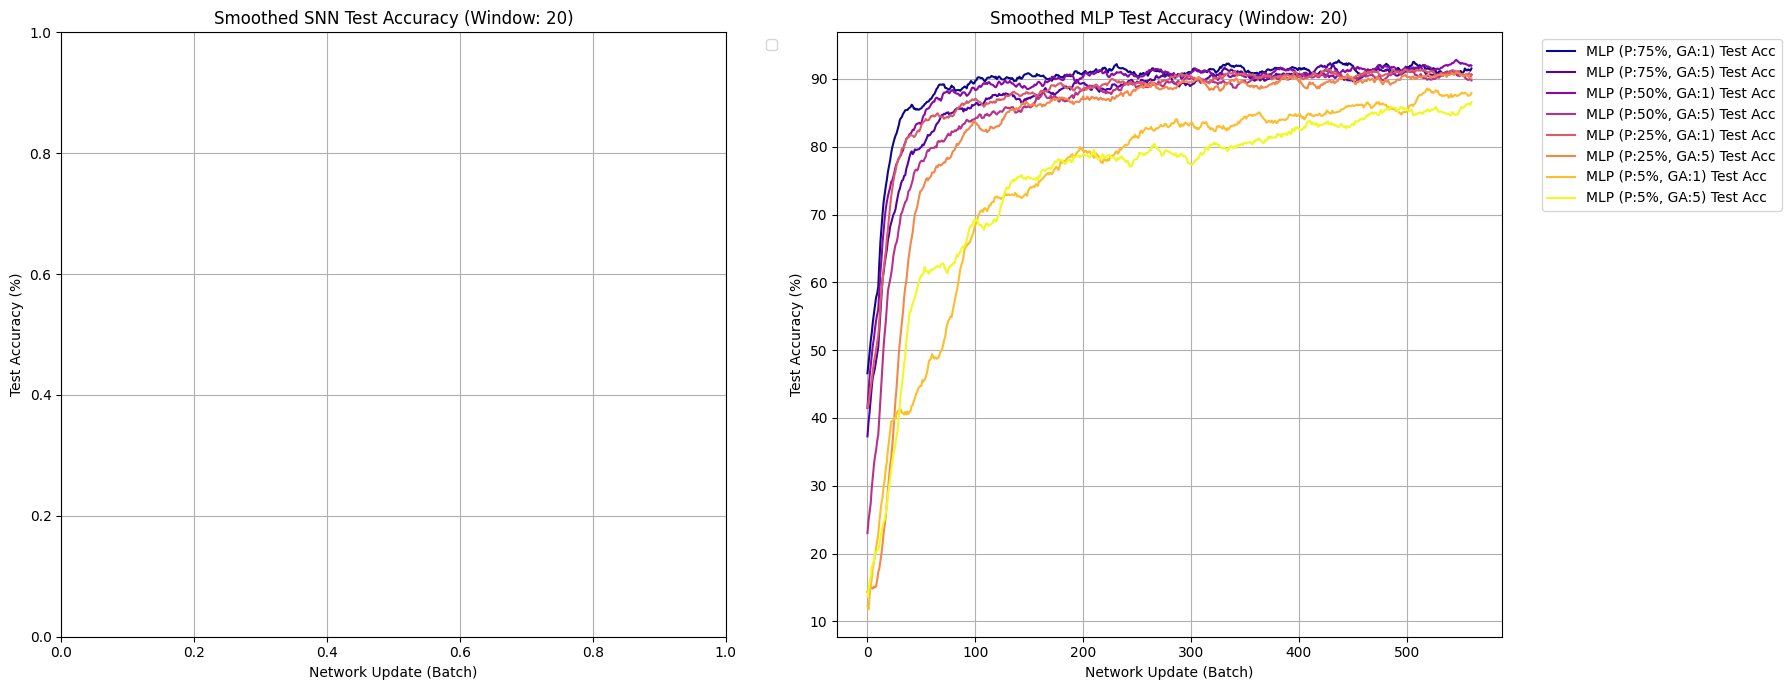

/tmp/ipykernel_2729/2050135691.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


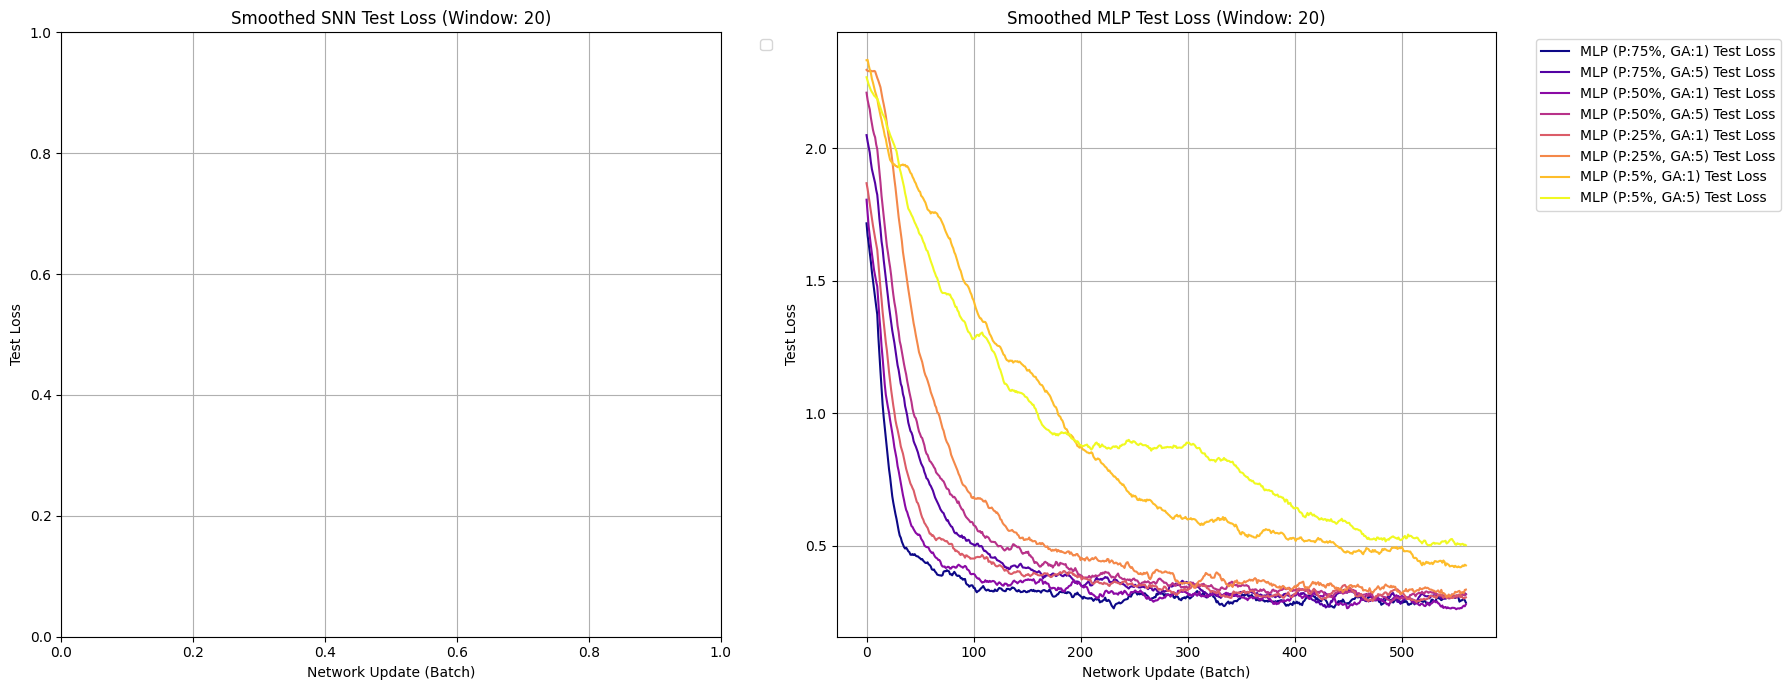

In [ ]:
# --- Apply smoothing to all collected histories (SNN and MLP) ---
SMOOTHING_WINDOW = 20 # Re-using the same smoothing window

for key, histories in all_snn_prob_delayed_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

for key, histories in all_mlp_prob_delayed_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

# --- Display comparative metrics (text tables) ---
print("\n--- SNN Performance Comparison (Probabilistic Loss & Delayed Aggregation) ---")
snn_prob_delayed_comparison_data = []
for key, results in all_snn_prob_delayed_results.items():
    prob, interval = key
    final_test_acc = results['smoothed_test_acc'][-1] * 100 if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc']) * 100
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    snn_prob_delayed_comparison_data.append({
        'Model': f'SNN (Prob: {prob*100:.0f}%, Delay: {interval})',
        'Final Test Accuracy (%)': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum %)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch:.2f}%'
    })

snn_prob_delayed_comparison_df = pd.DataFrame(snn_prob_delayed_comparison_data)
print(snn_prob_delayed_comparison_df.to_markdown(index=False))

print("\n--- MLP Performance Comparison (Probabilistic Loss & Delayed Gradient Accumulation) ---")
mlp_prob_delayed_comparison_data = []
for key, results in all_mlp_prob_delayed_results.items():
    prob, ga_interval = key
    final_test_acc = results['smoothed_test_acc'][-1] * 100 if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc']) * 100
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    mlp_prob_delayed_comparison_data.append({
        'Model': f'MLP (Prob: {prob*100:.0f}%, GA: {ga_interval})',
        'Final Test Accuracy (%)': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum %)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch:.2f}%'
    })

mlp_prob_delayed_comparison_df = pd.DataFrame(mlp_prob_delayed_comparison_data)
print(mlp_prob_delayed_comparison_df.to_markdown(index=False))

# --- Plotting the smoothed results for a selected subset ---
# For better readability, we'll plot a subset of results, e.g., for Delay/GA = 1 and 5

plot_intervals = [1, 5] # Selected delay/GA intervals for plotting
plot_probs = loss_probabilities # All probabilities

plt.figure(figsize=(18, 7))

# SNN Accuracy Plot
plt.subplot(1, 2, 1)
snn_colors = plt.cm.viridis(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for interval in plot_intervals:
        key = (prob, interval)
        if key in all_snn_prob_delayed_results:
            results = all_snn_prob_delayed_results[key]
            plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'SNN (P:{prob*100:.0f}%, D:{interval}) Test Acc', color=snn_colors[color_idx])
            color_idx += 1
plt.title(f'Smoothed SNN Test Accuracy (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# MLP Accuracy Plot
plt.subplot(1, 2, 2)
mlp_colors = plt.cm.plasma(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for ga_interval in plot_intervals:
        key = (prob, ga_interval)
        if key in all_mlp_prob_delayed_results:
            results = all_mlp_prob_delayed_results[key]
            plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'MLP (P:{prob*100:.0f}%, GA:{ga_interval}) Test Acc', color=mlp_colors[color_idx])
            color_idx += 1
plt.title(f'Smoothed MLP Test Accuracy (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 7))

# SNN Loss Plot
plt.subplot(1, 2, 1)
snn_colors_loss = plt.cm.viridis(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for interval in plot_intervals:
        key = (prob, interval)
        if key in all_snn_prob_delayed_results:
            results = all_snn_prob_delayed_results[key]
            plt.plot(results['smoothed_test_loss'], label=f'SNN (P:{prob*100:.0f}%, D:{interval}) Test Loss', color=snn_colors_loss[color_idx])
            color_idx += 1
plt.title(f'Smoothed SNN Test Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# MLP Loss Plot
plt.subplot(1, 2, 2)
mlp_colors_loss = plt.cm.plasma(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for ga_interval in plot_intervals:
        key = (prob, ga_interval)
        if key in all_mlp_prob_delayed_results:
            results = all_mlp_prob_delayed_results[key]
            plt.plot(results['smoothed_test_loss'], label=f'MLP (P:{prob*100:.0f}%, GA:{ga_interval}) Test Loss', color=mlp_colors_loss[color_idx])
            color_idx += 1
plt.title(f'Smoothed MLP Test Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()



--- SNN Performance Comparison (Probabilistic Loss & Delayed Aggregation) ---
| Model                      | Final Test Accuracy (%)   |   AUC Test Accuracy (Sum %) | Average Test Accuracy per Batch (%)   |
|:---------------------------|:--------------------------|----------------------------:|:--------------------------------------|
| SNN (Prob: 75%, Delay: 1)  | 93.32%                    |                     50825.1 | 90.60%                                |
| SNN (Prob: 75%, Delay: 2)  | 88.85%                    |                     50002   | 89.13%                                |
| SNN (Prob: 75%, Delay: 5)  | 91.97%                    |                     51240.5 | 91.34%                                |
| SNN (Prob: 75%, Delay: 10) | 89.42%                    |                     49896.4 | 88.94%                                |
| SNN (Prob: 75%, Delay: 25) | 81.53%                    |                     46065.5 | 82.11%                                |
| SNN (Prob: 50%, 

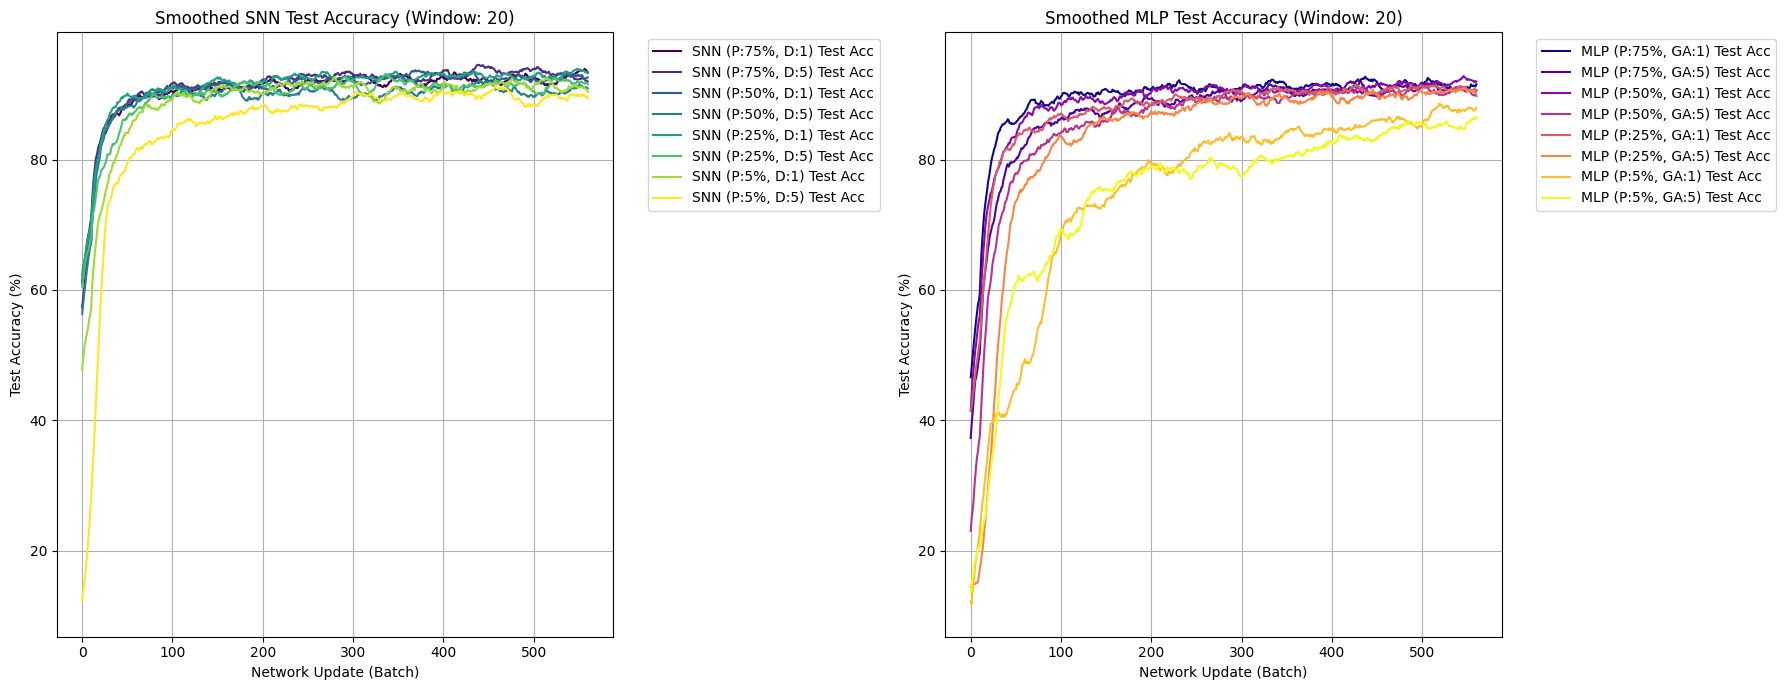

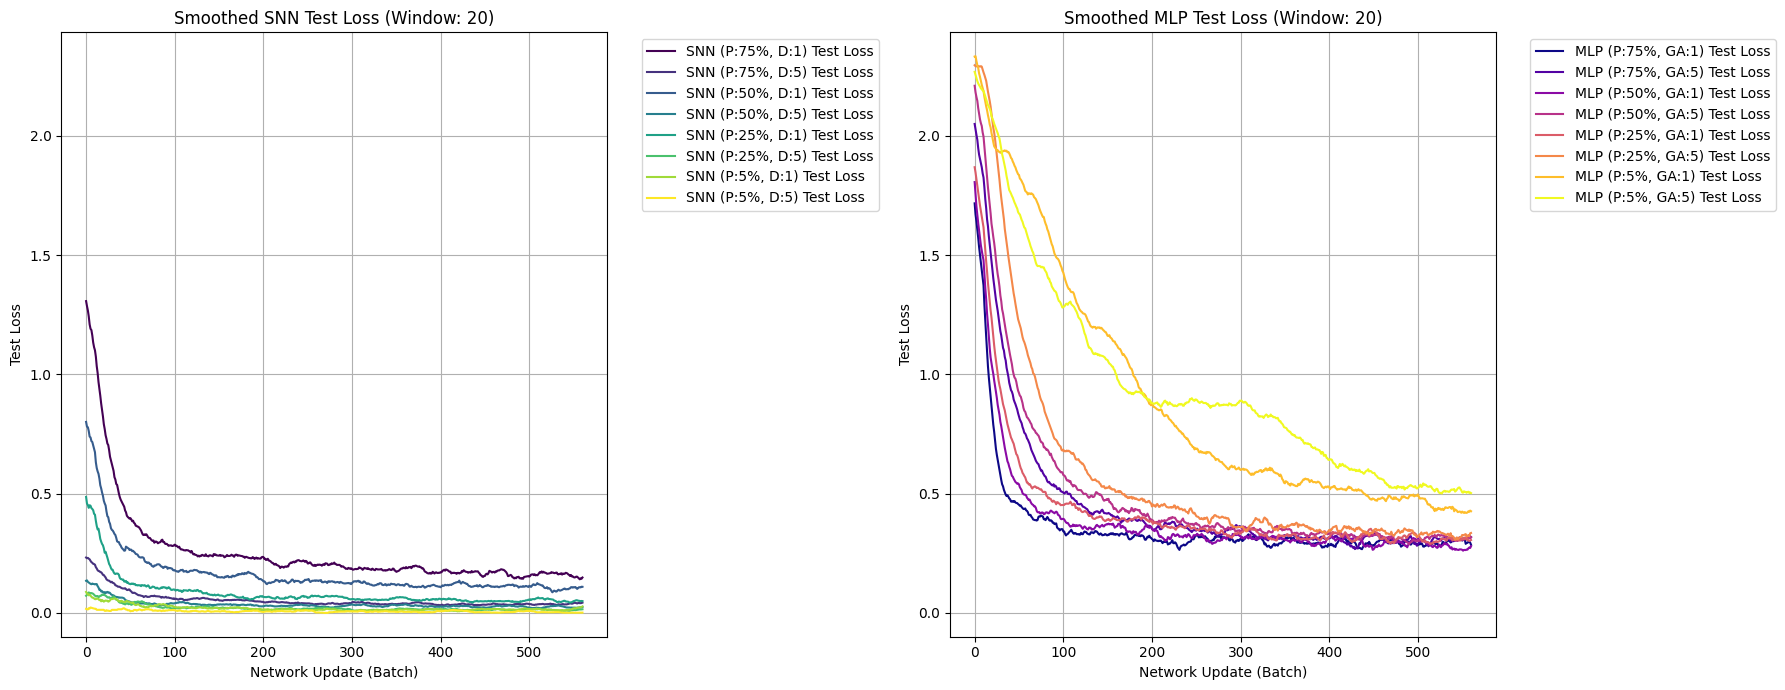

In [ ]:
# --- Apply smoothing to all collected histories (SNN and MLP) ---
SMOOTHING_WINDOW = 20 # Re-using the same smoothing window

for key, histories in all_snn_prob_delayed_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

for key, histories in all_mlp_prob_delayed_results.items():
    histories['smoothed_train_acc'] = smooth_curve(histories['train_acc'], SMOOTHING_WINDOW)
    histories['smoothed_test_acc'] = smooth_curve(histories['test_acc'], SMOOTHING_WINDOW)
    histories['smoothed_train_loss'] = smooth_curve(histories['train_loss'], SMOOTHING_WINDOW)
    histories['smoothed_test_loss'] = smooth_curve(histories['test_loss'], SMOOTHING_WINDOW)

# --- Display comparative metrics (text tables) ---
print("\n--- SNN Performance Comparison (Probabilistic Loss & Delayed Aggregation) ---")
snn_prob_delayed_comparison_data = []
for key, results in all_snn_prob_delayed_results.items():
    prob, interval = key
    final_test_acc = results['smoothed_test_acc'][-1] * 100 if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc']) * 100
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    snn_prob_delayed_comparison_data.append({
        'Model': f'SNN (Prob: {prob*100:.0f}%, Delay: {interval})',
        'Final Test Accuracy (%)': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum %)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch:.2f}%'
    })

snn_prob_delayed_comparison_df = pd.DataFrame(snn_prob_delayed_comparison_data)
print(snn_prob_delayed_comparison_df.to_markdown(index=False))

print("\n--- MLP Performance Comparison (Probabilistic Loss & Delayed Gradient Accumulation) ---")
mlp_prob_delayed_comparison_data = []
for key, results in all_mlp_prob_delayed_results.items():
    prob, ga_interval = key
    final_test_acc = results['smoothed_test_acc'][-1] * 100 if results['smoothed_test_acc'] else 0
    auc_test_acc = sum(results['smoothed_test_acc']) * 100
    num_batches = len(results['smoothed_test_acc'])
    avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

    mlp_prob_delayed_comparison_data.append({
        'Model': f'MLP (Prob: {prob*100:.0f}%, GA: {ga_interval})',
        'Final Test Accuracy (%)': f'{final_test_acc:.2f}%',
        'AUC Test Accuracy (Sum %)': f'{auc_test_acc:.2f}',
        'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch:.2f}%'
    })

mlp_prob_delayed_comparison_df = pd.DataFrame(mlp_prob_delayed_comparison_data)
print(mlp_prob_delayed_comparison_df.to_markdown(index=False))

# --- Plotting the smoothed results for a selected subset ---
# For better readability, we'll plot a subset of results, e.g., for Delay/GA = 1 and 5

plot_intervals = [1, 5] # Selected delay/GA intervals for plotting
plot_probs = loss_probabilities # All probabilities

# Calculate global min/max for accuracy and loss across all SNN and MLP smoothed test results
all_test_accs = []
all_test_losses = []

for key, histories in all_snn_prob_delayed_results.items():
    if key[1] in plot_intervals and key[0] in plot_probs: # Consider only the plotted subsets for range
        all_test_accs.extend(np.array(histories['smoothed_test_acc']) * 100)
        all_test_losses.extend(histories['smoothed_test_loss'])

for key, histories in all_mlp_prob_delayed_results.items():
    if key[1] in plot_intervals and key[0] in plot_probs: # Consider only the plotted subsets for range
        all_test_accs.extend(np.array(histories['smoothed_test_acc']) * 100)
        all_test_losses.extend(histories['smoothed_test_loss'])

global_min_acc = min(all_test_accs) if all_test_accs else 0
global_max_acc = max(all_test_accs) if all_test_accs else 100
global_min_loss = min(all_test_losses) if all_test_losses else 0
global_max_loss = max(all_test_losses) if all_test_losses else 2.5 # A reasonable default max for loss

plt.figure(figsize=(18, 7))

# SNN Accuracy Plot
plt.subplot(1, 2, 1)
snn_colors = plt.cm.viridis(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for interval in plot_intervals:
        key = (prob, interval)
        if key in all_snn_prob_delayed_results:
            results = all_snn_prob_delayed_results[key]
            plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'SNN (P:{prob*100:.0f}%, D:{interval}) Test Acc', color=snn_colors[color_idx])
            color_idx += 1
plt.title(f'Smoothed SNN Test Accuracy (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.ylim(global_min_acc - 5, global_max_acc + 5) # Apply global Y-limits for comparability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# MLP Accuracy Plot
plt.subplot(1, 2, 2)
mlp_colors = plt.cm.plasma(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for ga_interval in plot_intervals:
        key = (prob, ga_interval)
        if key in all_mlp_prob_delayed_results:
            results = all_mlp_prob_delayed_results[key]
            plt.plot(np.array(results['smoothed_test_acc'])*100, label=f'MLP (P:{prob*100:.0f}%, GA:{ga_interval}) Test Acc', color=mlp_colors[color_idx])
            color_idx += 1
plt.title(f'Smoothed MLP Test Accuracy (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Accuracy (%)')
plt.ylim(global_min_acc - 5, global_max_acc + 5) # Apply global Y-limits for comparability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 7))

# SNN Loss Plot
plt.subplot(1, 2, 1)
snn_colors_loss = plt.cm.viridis(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for interval in plot_intervals:
        key = (prob, interval)
        if key in all_snn_prob_delayed_results:
            results = all_snn_prob_delayed_results[key]
            plt.plot(results['smoothed_test_loss'], label=f'SNN (P:{prob*100:.0f}%, D:{interval}) Test Loss', color=snn_colors_loss[color_idx])
            color_idx += 1
plt.title(f'Smoothed SNN Test Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.ylim(global_min_loss - 0.1, global_max_loss + 0.1) # Apply global Y-limits for comparability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# MLP Loss Plot
plt.subplot(1, 2, 2)
mlp_colors_loss = plt.cm.plasma(np.linspace(0, 1, len(plot_probs) * len(plot_intervals)))
color_idx = 0
for prob in plot_probs:
    for ga_interval in plot_intervals:
        key = (prob, ga_interval)
        if key in all_mlp_prob_delayed_results:
            results = all_mlp_prob_delayed_results[key]
            plt.plot(results['smoothed_test_loss'], label=f'MLP (P:{prob*100:.0f}%, GA:{ga_interval}) Test Loss', color=mlp_colors_loss[color_idx])
            color_idx += 1
plt.title(f'Smoothed MLP Test Loss (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Test Loss')
plt.ylim(global_min_loss - 0.1, global_max_loss + 0.1) # Apply global Y-limits for comparability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

Starting training for SNN Kolen-Pollack...
SNN Kolen-Pollack Epoch 0, Iteration 0
SNN Kolen-Pollack Train Set Loss: 2.37
SNN Kolen-Pollack Test Set Loss: 2.16
SNN Kolen-Pollack Train set accuracy for a single minibatch: 45.31%
SNN Kolen-Pollack Test set accuracy for a single minibatch: 30.47%


SNN Kolen-Pollack Epoch 1, Iteration 20
SNN Kolen-Pollack Train Set Loss: 0.45
SNN Kolen-Pollack Test Set Loss: 0.40
SNN Kolen-Pollack Train set accuracy for a single minibatch: 89.06%
SNN Kolen-Pollack Test set accuracy for a single minibatch: 92.19%


SNN Kolen-Pollack Epoch 3, Iteration 10
SNN Kolen-Pollack Train Set Loss: 0.28
SNN Kolen-Pollack Test Set Loss: 0.27
SNN Kolen-Pollack Train set accuracy for a single minibatch: 89.84%
SNN Kolen-Pollack Test set accuracy for a single minibatch: 95.31%




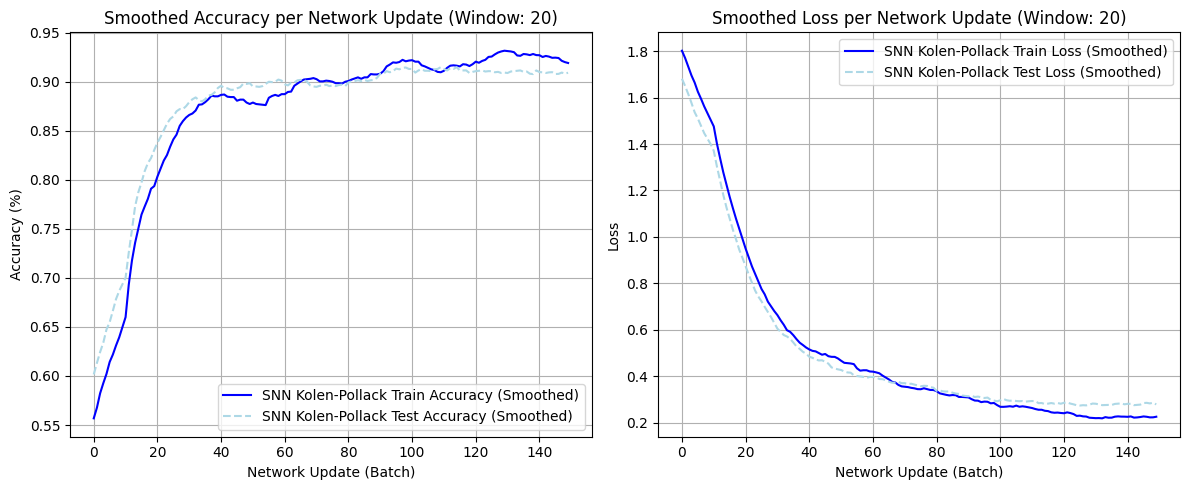


--- SNN Kolen-Pollack Performance Summary ---
| Metric                          | Value    |
|:--------------------------------|:---------|
| Final Test Accuracy             | 90.91%   |
| AUC Test Accuracy (Sum)         | 13129.17 |
| Average Test Accuracy per Batch | 87.53%   |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

# Assuming SNN_MLP, device, config, train_loader, test_loader, loss, smooth_curve are available from previous cells.

def train_snn_kolen_pollack(snn_model, snn_optimizer, train_loader, test_loader,
                            num_epochs, num_snn_timesteps, model_name="SNN Kolen-Pollack"):
    """
    Trains an SNN model using backpropagation through time (BPTT),
    which is the modern implementation of the Kolen-Pollack algorithm concept
    for feedforward SNNs unrolled over time.

    Loss is accumulated over all timesteps for the backward pass.

    Arguments:
    - snn_model (torch model): SNN model to train (e.g., SNN_MLP).
    - snn_optimizer (torch optimizer): Optimizer to use to update the model.
    - train_loader (torch dataloader): Dataloader for training data.
    - test_loader (torch dataloader): Dataloader for test data.
    - num_epochs (int): Number of epochs to train the model.
    - num_snn_timesteps (int): Number of timesteps to unroll the SNN for.
    - model_name (str, optional): Name for the training run, for printing/plotting.

    Returns:
    - loss_hist (list): List of training loss values per batch.
    - test_loss_hist (list): List of test loss values per batch.
    - train_acc_hist (list): List of training accuracy values per batch.
    - test_acc_hist (list): List of test accuracy values per batch.
    """
    loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    counter = 0
    dtype = torch.float

    print(f"Starting training for {model_name}...")

    # Helper function to print accuracy for a single batch
    def print_batch_accuracy_kp(data, targets, train=False):
        output, _ = snn_model(data.view(config.BATCH_SIZE, -1))
        _, idx = output.sum(dim=0).max(1)
        acc = np.mean((targets == idx).detach().cpu().numpy())
        if train:
            print(f"{model_name} Train set accuracy for a single minibatch: {acc*100:.2f}%")
        else:
            print(f"{model_name} Test set accuracy for a single minibatch: {acc*100:.2f}%")

    # Helper function to print training progress
    def train_printer_kp(
        data, targets, epoch,
        current_counter, iter_counter,
            loss_hist_curr, test_loss_hist_curr, test_data, test_targets):
        print(f"{model_name} Epoch {epoch}, Iteration {iter_counter}")
        print(f"{model_name} Train Set Loss: {loss_hist_curr[current_counter]:.2f}")
        print(f"{model_name} Test Set Loss: {test_loss_hist_curr[current_counter]:.2f}")
        print_batch_accuracy_kp(data, targets, train=True)
        print_batch_accuracy_kp(test_data, test_targets, train=False)
        print("\n")

    # Outer training loop
    for epoch in range(num_epochs):
        iter_counter = 0
        train_batch_iter = iter(train_loader)
        test_loader_iter = iter(test_loader)

        # Minibatch training loop
        for data, targets in train_batch_iter:
            data = data.to(device)
            targets = targets.to(device)

            # Forward pass
            snn_model.train()
            spk_rec, mem_rec = snn_model(data.view(config.BATCH_SIZE, -1))

            # Initialize loss and sum over all timesteps for Kolen-Pollack (BPTT)
            loss_val = torch.zeros((1), dtype=dtype, device=device)
            for step in range(num_snn_timesteps):
                loss_val += loss(mem_rec[step], targets)

            # Normalize SNN loss by number of timesteps
            loss_val /= num_snn_timesteps

            # Gradient calculation + weight update (BPTT handled by autograd)
            snn_optimizer.zero_grad()
            loss_val.backward()
            snn_optimizer.step()

            # Store loss history
            loss_hist.append(loss_val.item())

            # Calculate and store training accuracy
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test set evaluation
            with torch.no_grad():
                snn_model.eval()
                try:
                    test_data, test_targets = next(test_loader_iter)
                except StopIteration:
                    # Reset test_loader_iter if exhausted within an epoch
                    test_loader_iter = iter(test_loader)
                    test_data, test_targets = next(test_loader_iter)

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                # Test set forward pass
                test_spk, test_mem = snn_model(test_data.view(config.BATCH_SIZE, -1))

                # Test set loss calculation (sum over all timesteps)
                test_loss = torch.zeros((1), dtype=dtype, device=device)
                for step in range(num_snn_timesteps):
                    test_loss += loss(test_mem[step], test_targets)

                test_loss /= num_snn_timesteps # Normalize test loss

                test_loss_hist.append(test_loss.item())

                # Calculate and store test accuracy
                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

                # Print train/test loss/accuracy periodically
                if counter % 50 == 0:
                    train_printer_kp(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter +=1
    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# Instantiate a new SNN model and optimizer for this experiment
snn_net_kolen_pollack = SNN_MLP().to(device)
snn_optimizer_kolen_pollack = torch.optim.Adam(snn_net_kolen_pollack.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

# Train the SNN using the Kolen-Pollack inspired BPTT approach
loss_hist_kolen_pollack, test_loss_hist_kolen_pollack, train_acc_hist_kolen_pollack, test_acc_hist_kolen_pollack = \
    train_snn_kolen_pollack(snn_net_kolen_pollack, snn_optimizer_kolen_pollack, train_loader, test_loader,
                            config.NUM_EPOCHS, config.NUM_SNN_TIMESTEPS, "SNN Kolen-Pollack")

# --- Plotting the results (smooth if the function is available) ---
# Assuming smooth_curve function is available from previous cells

SMOOTHING_WINDOW = 20 # Define a smoothing window size

smoothed_train_acc_kolen_pollack = smooth_curve(train_acc_hist_kolen_pollack, SMOOTHING_WINDOW)
smoothed_test_acc_kolen_pollack = smooth_curve(test_acc_hist_kolen_pollack, SMOOTHING_WINDOW)
smoothed_loss_hist_kolen_pollack = smooth_curve(loss_hist_kolen_pollack, SMOOTHING_WINDOW)
smoothed_test_loss_kolen_pollack = smooth_curve(test_loss_hist_kolen_pollack, SMOOTHING_WINDOW)

plt.figure(figsize=(12, 5))

# Plotting Accuracy
plt.subplot(1, 2, 1)
plt.plot(smoothed_train_acc_kolen_pollack, label='SNN Kolen-Pollack Train Accuracy (Smoothed)', color='blue')
plt.plot(smoothed_test_acc_kolen_pollack, label='SNN Kolen-Pollack Test Accuracy (Smoothed)', color='lightblue', linestyle='--')
plt.title(f'Smoothed Accuracy per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(smoothed_loss_hist_kolen_pollack, label='SNN Kolen-Pollack Train Loss (Smoothed)', color='blue')
plt.plot(smoothed_test_loss_kolen_pollack, label='SNN Kolen-Pollack Test Loss (Smoothed)', color='lightblue', linestyle='--')
plt.title(f'Smoothed Loss per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- SNN Kolen-Pollack Performance Summary ---")
final_test_acc = smoothed_test_acc_kolen_pollack[-1] * 100 if smoothed_test_acc_kolen_pollack else 0
auc_test_acc = sum(smoothed_test_acc_kolen_pollack) * 100
num_batches = len(smoothed_test_acc_kolen_pollack)
avg_test_acc_per_batch = (auc_test_acc / num_batches) if num_batches > 0 else 0

summary_data = [
    {'Metric': 'Final Test Accuracy', 'Value': f'{final_test_acc:.2f}%'},
    {'Metric': 'AUC Test Accuracy (Sum)', 'Value': f'{auc_test_acc:.2f}'},
    {'Metric': 'Average Test Accuracy per Batch', 'Value': f'{avg_test_acc_per_batch:.2f}%'}
]
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_markdown(index=False))


In [ ]:
#@title Train snn model
num_epochs = config.NUM_EPOCHS
loss_hist_snn = []
test_loss_hist_snn = []
train_acc_hist_snn = []  # New: Store training accuracy per minibatch
test_acc_hist_snn = []   # New: Store test accuracy per minibatch
counter = 0
num_steps = config.NUM_SNN_TIMESTEPS
dtype = torch.float

# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target
def print_batch_accuracy(data, targets, train=False):
    output, _ = snn_net(data.view(config.BATCH_SIZE, -1))
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())
    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")
def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

# Outer training loop
for epoch in range(num_epochs):
    iter_counter = 0
    train_batch = iter(train_loader)
    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)
        # forward pass
        snn_net.train()
        spk_rec, mem_rec = snn_net(data.view(BATCH_SIZE, -1))
        # initialize the loss & sum over time
        loss_val = torch.zeros((1), dtype=dtype, device=device)
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)
        loss_val /= num_steps # Normalize SNN loss by number of timesteps
        # Gradient calculation + weight update
        snn_optimizer.zero_grad()
        loss_val.backward()
        snn_optimizer.step()
        # Store loss history for future plotting
        loss_hist_snn.append(loss_val.item())

        # New: Calculate and store training accuracy
        _, predicted_train_labels = spk_rec.sum(dim=0).max(1) # Sum spikes over time and get the class with max spikes
        train_acc = (predicted_train_labels == targets).float().mean().item()
        train_acc_hist_snn.append(train_acc)

        # Test set
        with torch.no_grad():
            snn_net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)
            # Test set forward pass
            test_spk, test_mem = snn_net(test_data.view(BATCH_SIZE, -1))
            # Test set loss
            test_loss = torch.zeros((1), dtype=dtype, device=device)
            for step in range(num_steps):

                  test_loss += loss(test_mem[step], test_targets)
            test_loss /= num_steps # Normalize SNN test loss by number of timesteps
            test_loss_hist_snn.append(test_loss.item())

            # New: Calculate and store test accuracy
            _, predicted_test_labels = test_spk.sum(dim=0).max(1)
            test_acc = (predicted_test_labels == test_targets).float().mean().item()
            test_acc_hist_snn.append(test_acc)

            # Print train/test loss/accuracy
            if counter % 50 == 0:
                train_printer(
                    data, targets, epoch,
                    counter, iter_counter,
                    loss_hist_snn, test_loss_hist_snn,
                    test_data, test_targets)
            counter += 1
            iter_counter +=1

Epoch 0, Iteration 0
Train Set Loss: 2.42
Test Set Loss: 2.21
Train set accuracy for a single minibatch: 46.88%
Test set accuracy for a single minibatch: 21.09%


Epoch 1, Iteration 20
Train Set Loss: 0.49
Test Set Loss: 0.32
Train set accuracy for a single minibatch: 85.16%
Test set accuracy for a single minibatch: 86.72%


Epoch 3, Iteration 10
Train Set Loss: 0.24
Test Set Loss: 0.28
Train set accuracy for a single minibatch: 88.28%
Test set accuracy for a single minibatch: 85.16%




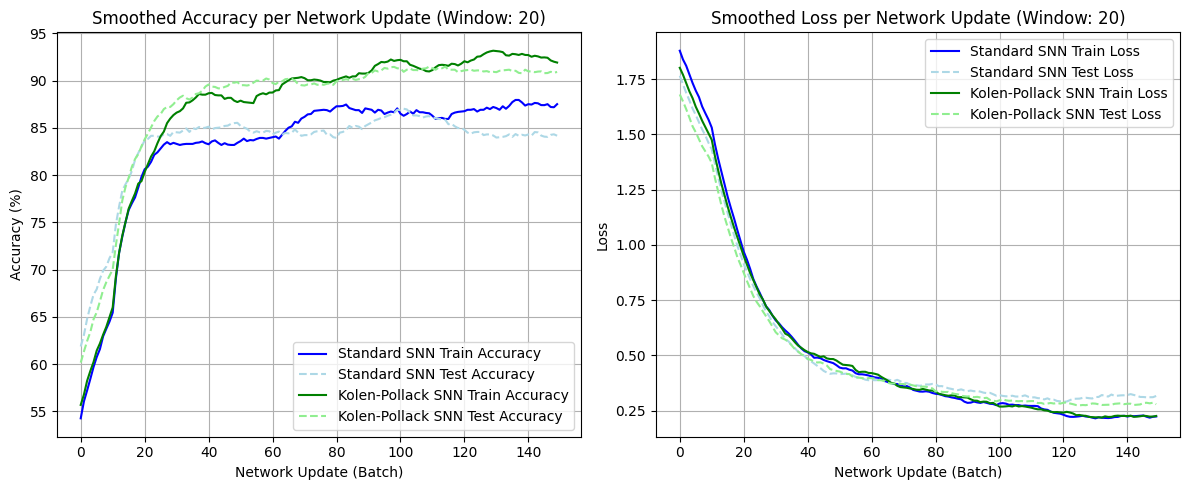


--- SNN Performance Comparison (Standard vs. Kolen-Pollack) ---
| Model             | Final Test Accuracy (%)   |   AUC Test Accuracy (Sum %) | Average Test Accuracy per Batch (%)   |
|:------------------|:--------------------------|----------------------------:|:--------------------------------------|
| Standard SNN      | 84.16%                    |                     12494   | 83.29%                                |
| Kolen-Pollack SNN | 90.91%                    |                     13129.2 | 87.53%                                |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming all necessary history lists (loss_hist_snn, test_loss_hist_snn, train_acc_hist_snn, test_acc_hist_snn,
# loss_hist_kolen_pollack, test_loss_hist_kolen_pollack, train_acc_hist_kolen_pollack, test_acc_hist_kolen_pollack)
# and the smooth_curve function are available from previous executions.

SMOOTHING_WINDOW = 20 # Define a smoothing window size

# --- Smooth the histories for the standard SNN (from cell d9ewEcvuPyF5) ---
smoothed_train_acc_snn = smooth_curve(train_acc_hist_snn, SMOOTHING_WINDOW)
smoothed_test_acc_snn = smooth_curve(test_acc_hist_snn, SMOOTHING_WINDOW)
smoothed_loss_hist_snn = smooth_curve(loss_hist_snn, SMOOTHING_WINDOW)
smoothed_test_loss_snn = smooth_curve(test_loss_hist_snn, SMOOTHING_WINDOW)

# --- Smooth the histories for the Kolen-Pollack SNN (from cell 47xSUk__D4iL) ---
smoothed_train_acc_kolen_pollack = smooth_curve(train_acc_hist_kolen_pollack, SMOOTHING_WINDOW)
smoothed_test_acc_kolen_pollack = smooth_curve(test_acc_hist_kolen_pollack, SMOOTHING_WINDOW)
smoothed_loss_hist_kolen_pollack = smooth_curve(loss_hist_kolen_pollack, SMOOTHING_WINDOW)
smoothed_test_loss_kolen_pollack = smooth_curve(test_loss_hist_kolen_pollack, SMOOTHING_WINDOW)

# --- Plotting the smoothed results for comparison ---
plt.figure(figsize=(12, 5))

# Plotting Accuracy
plt.subplot(1, 2, 1)
plt.plot(np.array(smoothed_train_acc_snn)*100, label='Standard SNN Train Accuracy', color='blue')
plt.plot(np.array(smoothed_test_acc_snn)*100, label='Standard SNN Test Accuracy', color='lightblue', linestyle='--')
plt.plot(np.array(smoothed_train_acc_kolen_pollack)*100, label='Kolen-Pollack SNN Train Accuracy', color='green')
plt.plot(np.array(smoothed_test_acc_kolen_pollack)*100, label='Kolen-Pollack SNN Test Accuracy', color='lightgreen', linestyle='--')
plt.title(f'Smoothed Accuracy per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(smoothed_loss_hist_snn, label='Standard SNN Train Loss', color='blue')
plt.plot(smoothed_test_loss_snn, label='Standard SNN Test Loss', color='lightblue', linestyle='--')
plt.plot(smoothed_loss_hist_kolen_pollack, label='Kolen-Pollack SNN Train Loss', color='green')
plt.plot(smoothed_test_loss_kolen_pollack, label='Kolen-Pollack SNN Test Loss', color='lightgreen', linestyle='--')
plt.title(f'Smoothed Loss per Network Update (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Performance Summary ---
print("\n--- SNN Performance Comparison (Standard vs. Kolen-Pollack) ---")

comparison_data = []

# Standard SNN Metrics
final_test_acc_snn = smoothed_test_acc_snn[-1] * 100 if smoothed_test_acc_snn else 0
auc_test_acc_snn = sum(smoothed_test_acc_snn) * 100
num_batches_snn = len(smoothed_test_acc_snn)
avg_test_acc_per_batch_snn = (auc_test_acc_snn / num_batches_snn) if num_batches_snn > 0 else 0
comparison_data.append({
    'Model': 'Standard SNN',
    'Final Test Accuracy (%)': f'{final_test_acc_snn:.2f}%',
    'AUC Test Accuracy (Sum %)': f'{auc_test_acc_snn:.2f}',
    'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch_snn:.2f}%'
})

# Kolen-Pollack SNN Metrics
final_test_acc_kolen_pollack = smoothed_test_acc_kolen_pollack[-1] * 100 if smoothed_test_acc_kolen_pollack else 0
auc_test_acc_kolen_pollack = sum(smoothed_test_acc_kolen_pollack) * 100
num_batches_kolen_pollack = len(smoothed_test_acc_kolen_pollack)
avg_test_acc_per_batch_kolen_pollack = (auc_test_acc_kolen_pollack / num_batches_kolen_pollack) if num_batches_kolen_pollack > 0 else 0
comparison_data.append({
    'Model': 'Kolen-Pollack SNN',
    'Final Test Accuracy (%)': f'{final_test_acc_kolen_pollack:.2f}%',
    'AUC Test Accuracy (Sum %)': f'{auc_test_acc_kolen_pollack:.2f}',
    'Average Test Accuracy per Batch (%)': f'{avg_test_acc_per_batch_kolen_pollack:.2f}%'
})

summary_df = pd.DataFrame(comparison_data)
print(summary_df.to_markdown(index=False))
